In [21]:
import yaml
import numpy as np
from pathlib import Path
from dotmap import DotMap
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use matplotlib's tex rendering
import matplotlib
matplotlib.rcParams['text.usetex'] = True

In [22]:
n_agents = 10
problem_type = "hard"
risk_buckets = [0, 0.25, 0.5, 0.75, 1.0]
method_titles = ["Constrained", "Constrained\nRisk Search", "Lagrangian\nSearch", "Biobjective\nSearch", "Risk Bounded\nUniform Search"]
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#a55194", "#393b79"]

#### Extract the metrics from records

In [23]:
def extract_multi_agent_metrics(records, num_agents, deltas, skip_indices=[]):
    success_rate = 0.0
    mean_steps = []
    mean_rewards = []
    sum_cumulative_costs = []
    for idx, record in enumerate(records):
        if idx in skip_indices:
            continue
        steps = []
        rewards = []
        successes = []
        cumulative_costs = []
        if len(record[0]) == 0:
            continue
        for i in range(num_agents):
            successes.append(record[i]["success"])
            cumulative_costs.append(record[i]["cumulative_costs"])
        all_success = all(successes)
        if all_success and np.sum(cumulative_costs) <= deltas[idx]:
            success_rate += 1
            for i in range(num_agents):
                steps.append(record[i]["steps"])
                rewards.append(record[i]["rewards"])
        
            mean_steps.append(np.mean(steps))
            mean_rewards.append(np.mean(rewards))
            sum_cumulative_costs.append(np.sum(cumulative_costs))

    metrics = {
        'mean_steps': mean_steps,
        'mean_rewards': mean_rewards,
        'sum_cumulative_costs': sum_cumulative_costs,
        'success_rate': success_rate / (len(records) - len(skip_indices)),
    }

    return metrics

## Comparisons

In [31]:
def plot_grouped_boxplot_pretty_ax(methods, metrics_over_buckets, method_titles, metric_key, title, ylabel, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))
    else:
        ax.cla()

    num_buckets = len(risk_buckets)
    num_methods = len(methods)

    box_width = 0.12
    group_width = box_width * num_methods
    offsets = np.linspace(-group_width / 2, group_width / 2, num_methods)

    missing = []
    for i, (method, label) in enumerate(zip(methods, method_titles)):
        method_data = []
        positions   = []
        for j, rp in enumerate(risk_buckets):
            vals = metrics_over_buckets[rp].get(method, {}).get(metric_key, [])
            method_data.append(vals)
            positions.append(j + offsets[i])

        if method_data:
            ax.boxplot(
                method_data,
                positions=positions,
                widths=box_width,
                patch_artist=True,
                boxprops=dict(facecolor=palette[i], edgecolor='black', linewidth=1.2),
                medianprops=dict(color='black', linewidth=1.2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3)
            )
            for pos, vals in zip(positions, method_data):
                if len(vals) == 0:
                    missing.append((pos, label))

    for j in range(num_buckets):
        if j % 2 == 1:
            ax.axvspan(j - 0.5, j + 0.5, color='black', alpha=0.07)

    ymin, ymax = ax.get_ylim()
    y_mark = ymin + 0.4 * (ymax - ymin)
    for x, lbl in missing:
        stripped_lbl = lbl.replace("\n", " ")
        ax.text(x, y_mark, f"No success: {stripped_lbl}", color='red', rotation=90,
                ha='center', va='center', fontsize=9)

    ax.set_xticks(range(num_buckets))
    ax.set_xticklabels([f"{int(r*100)}%" for r in risk_buckets], fontsize=10)
    ax.set_xlabel("Risk Bucket", fontsize=12, color='black')
    ax.set_ylabel(ylabel, fontsize=12, color='black')
    ax.set_title(title + " (" + r"$\downarrow$" + ")", fontsize=13, color='black')
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

    handles = [Line2D([0],[0], color=palette[i], lw=6) for i in range(len(methods))]
    return handles, method_titles

In [25]:
def plot_grouped_bars(methods, metrics_over_buckets, method_titles, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    else:
        ax.cla()

    num_buckets = len(risk_buckets)
    num_methods = len(methods)

    bar_width   = 0.8 / num_methods
    x           = np.arange(num_buckets)

    for j in range(num_buckets):
        if j % 2 == 1:
            ax.axvspan(j - 0.5, j + 0.5, facecolor="lightgrey", alpha=0.1)

    handles = []
    labels  = []
    for i, (method, label) in enumerate(zip(methods, method_titles)):
        heights = [
            metrics_over_buckets[rp]
              .get(method, {})
              .get("success_rate", 0.0)
            for rp in risk_buckets
        ]
        bars = ax.bar(
            x + i * bar_width, heights,
            width=bar_width,
            color=palette[i % len(palette)],
            edgecolor="black",
            linewidth=1,
            alpha=0.8
        )
        handles.append(bars[0])
        labels.append(label)

        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.01,
                f"{h:.2f}",
                ha="center", va="bottom",
                fontsize=8, color="#333333",
                rotation=90
            )

    ax.set_xticks(x + (num_methods - 1) * bar_width / 2)
    ax.set_xticklabels([f"{int(r*100)}%" for r in risk_buckets], fontsize=10)
    ax.set_xlabel("Risk Bucket", fontsize=12, color="black")
    ax.set_ylabel("Success Rate", fontsize=12, color="black")
    ax.set_title(f"Success Rate (" + r"$\uparrow$" + ")", fontsize=13, color="black")
    ax.set_ylim(0, 1.1)

    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    ax.xaxis.grid(False)

    return handles, labels

In [26]:
methods=[
    # "unconstrained",
    # "unconstrained_reward_search",
    "constrained",
    # "constrained_reward_search",
    "constrained_risk_search",
    # "full_constrained_risk_search",
    "lagrangian_search",
    "biobjective_search",
]
rb_methods = [
    # "risk_budgeted_search",
    "risk_bounded_uniform_search",
    # "risk_bounded_utility_search",
    # "risk_bounded_inverse_utility_search",
]
method_titles = [
    # "Unconstrained",
    # "Unconstrained\nReward Search",
    "Constrained",
    # "Constrained\nReward Search",
    "Constrained\nRisk Search",
    # "Full\nConstrained\nRisk Search",
    "Lagrangian\nSearch",
    "Biobjective\nSearch",
    # "Risk Budgeted\nSearch",
    "Risk Bounded\nUniform Search",
    # "Risk Bounded\nUtility Search",
    # "Risk Bounded\nInverse Utility\nSearch",
]

In [27]:
def process_data(basedir, n_agents, problem_type):

    multi_agent_basedir = basedir / problem_type

    cbs_lb_data = np.load(multi_agent_basedir / "cbs_risk_bounds" / f"lb_{n_agents}.npy", allow_pickle=True)
    cbs_ub_data = np.load(multi_agent_basedir / "cbs_risk_bounds" / f"ub_{n_agents}.npy", allow_pickle=True)
    lb_data = np.load(multi_agent_basedir / "risk_bounds" / f"lb_{n_agents}.npy", allow_pickle=True)
    ub_data = np.load(multi_agent_basedir / "risk_bounds" / f"ub_{n_agents}.npy", allow_pickle=True)

    skip_indices = []
    for pb_idx in range(len(cbs_lb_data)):
        lb = max(lb_data[pb_idx], cbs_lb_data[pb_idx])
        ub = min(ub_data[pb_idx], cbs_ub_data[pb_idx])
        # lb = cbs_lb_data[pb_idx]
        # ub = cbs_ub_data[pb_idx]
        if lb == -1 or ub == -1 or lb > ub:
            skip_indices.append(pb_idx)

    metrics_over_buckets = {}
    for idx, risk_percent in enumerate(risk_buckets):
        metrics = {}

        deltas = []
        for pb_idx in range(len(cbs_lb_data)):
            if pb_idx in skip_indices:
                deltas.append(-1.0)
                continue
            lb = max(lb_data[pb_idx], cbs_lb_data[pb_idx])
            ub = min(ub_data[pb_idx], cbs_ub_data[pb_idx])
            # lb = cbs_lb_data[pb_idx]
            # ub = cbs_ub_data[pb_idx]
            delta = lb + risk_percent * (ub - lb)
            deltas.append(delta)

        for method in methods + rb_methods:
            method_records = np.load(multi_agent_basedir / f"{method}_records_{n_agents}.npy", allow_pickle=True)
            if method in rb_methods:
                method_records = method_records[idx]
            method_metrics = extract_multi_agent_metrics(method_records, n_agents, deltas, skip_indices=skip_indices)
            metrics[method] = method_metrics

        metrics_over_buckets[risk_percent] = metrics
    return metrics_over_buckets

In [ ]:
def plot_data(data, env_name, save=False):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)


    h1, labels= plot_grouped_bars(methods + rb_methods, data, method_titles, ax=axes[0])
    _, _ = plot_grouped_boxplot_pretty_ax(methods + rb_methods, data, method_titles, metric_key="mean_steps", title="Steps", ylabel="Mean Steps", ax=axes[1])
    _, _ = plot_grouped_boxplot_pretty_ax(methods + rb_methods, data, method_titles, metric_key="sum_cumulative_costs", title="Cumulative Cost", ylabel="Sum of Cumulative Cost", ax=axes[2])

    for ax in axes:
        # ax.set_xlabel("")
        ax.set_xlabel("Risk Percent (\%)", fontsize=12, color='black') # type: ignore
        ax.tick_params(axis='x', colors='black')
        ax.tick_params(axis='y', colors='black')
        ax.set_xticks(range(len(risk_buckets)))
        ax.set_xticklabels([f"{int(rb*100)}\%" for rb in risk_buckets], fontsize=10) # type: ignore
    for ax in axes[1:]:
        ax.set_xlim(-0.5, len(risk_buckets) - 0.5)

    # fig.supxlabel("Risk Percent (\%)", y=0.05, fontsize=14, color='black') # type: ignore
    env_title = env_name.replace("_", " ").title()
    fig.suptitle(f"Visual Environment (Scene: {env_title}, Agents: {n_agents}, Difficulty: {problem_type.title()})", y=0.95, fontsize=20, color='black')

    fig.legend(
        h1, labels,
        loc="lower center",
        bbox_to_anchor=(0.5,-0.08),
        ncol=5,
        frameon=False,
        fontsize=10,
        labelcolor='black'
    )

    plt.tight_layout(rect=(0, 0, 1, 0.95))
    if save:
        plt.savefig(f"pud/plots/figures/paper/habitatenv_{env_name}_{problem_type}_{n_agents}.svg", bbox_inches='tight')

Processing data for sc2_staging_08
Processing data for 5 agents in easy problem type


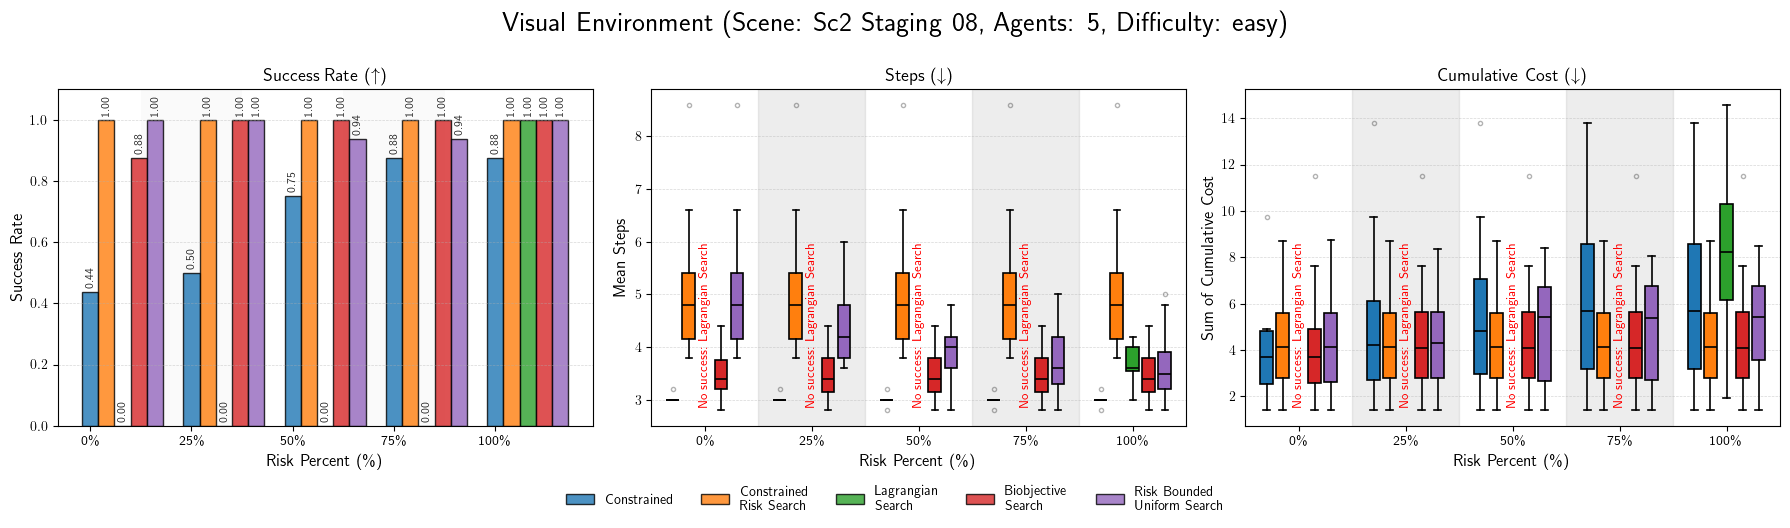

Processing data for 10 agents in easy problem type


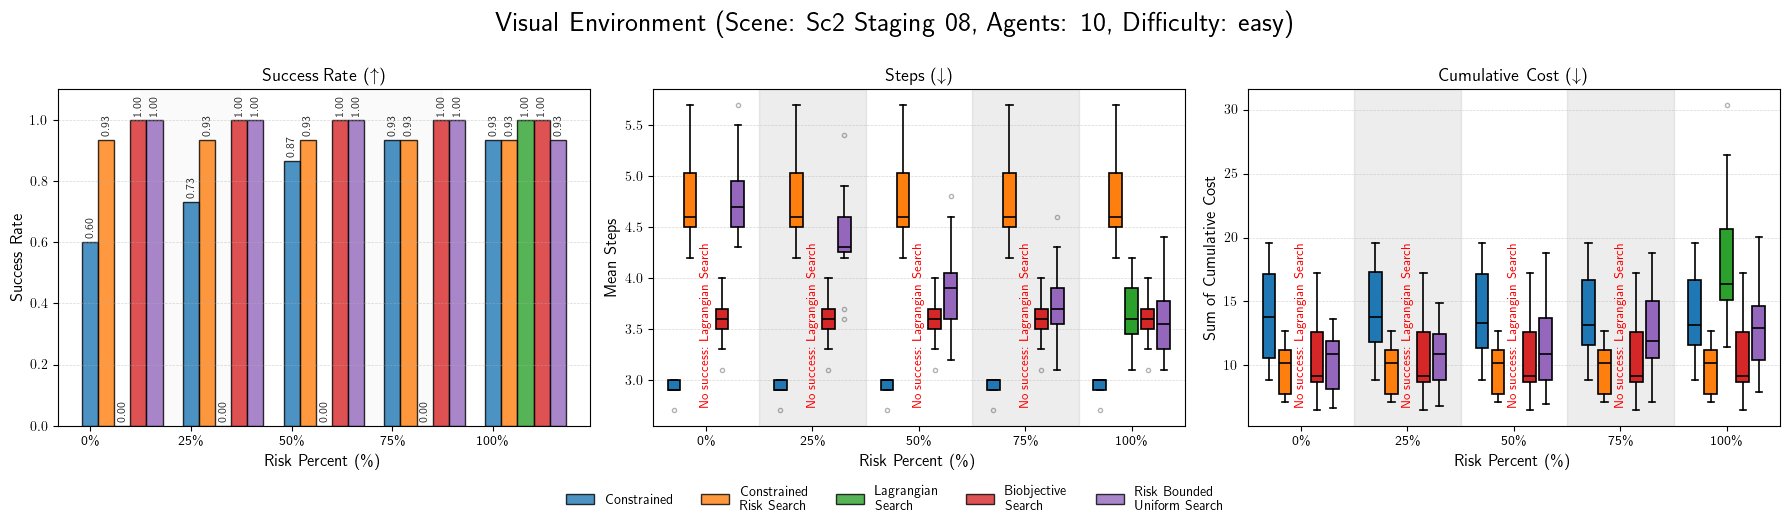

Processing data for 5 agents in medium problem type


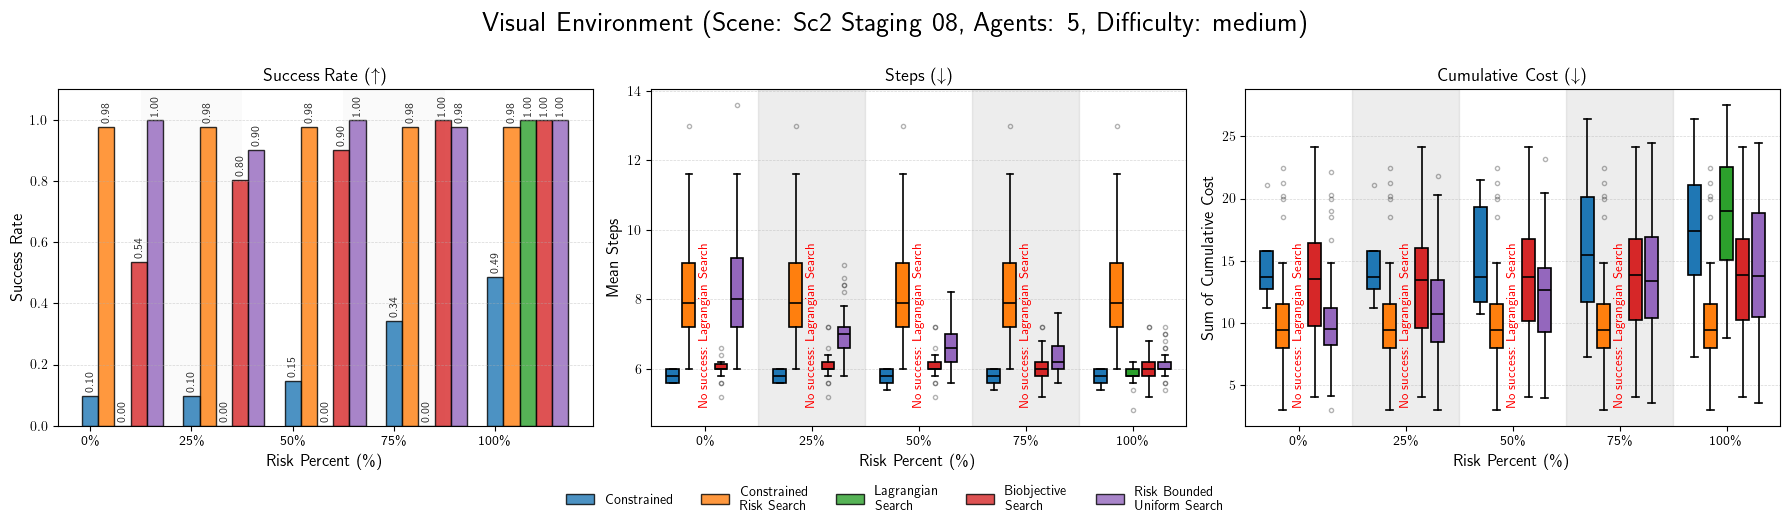

Processing data for 10 agents in medium problem type


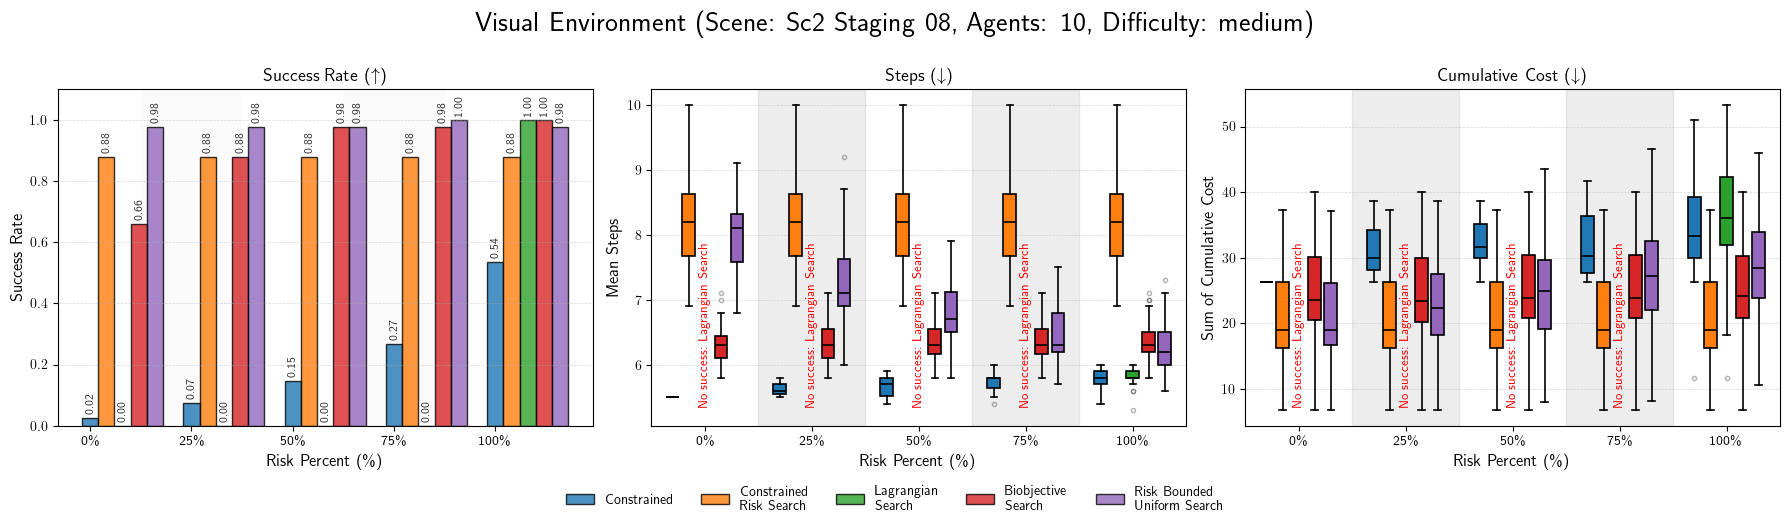

Processing data for 5 agents in hard problem type


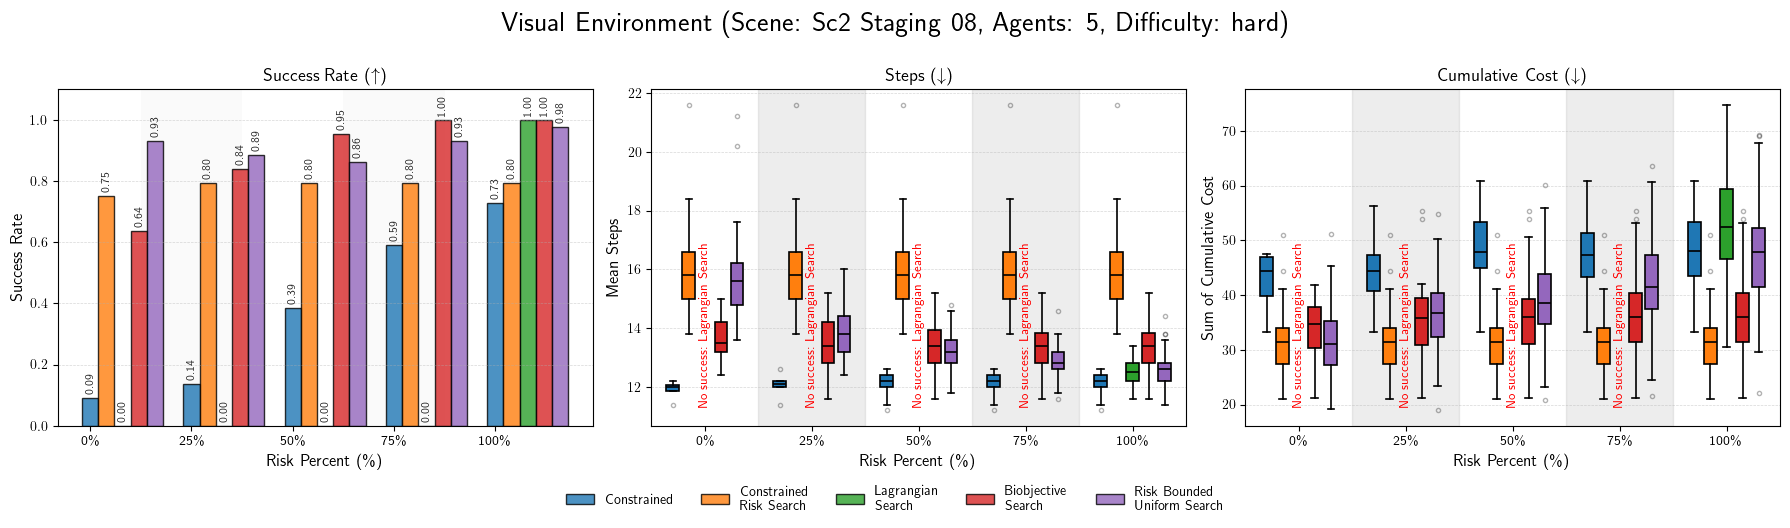

Processing data for 10 agents in hard problem type


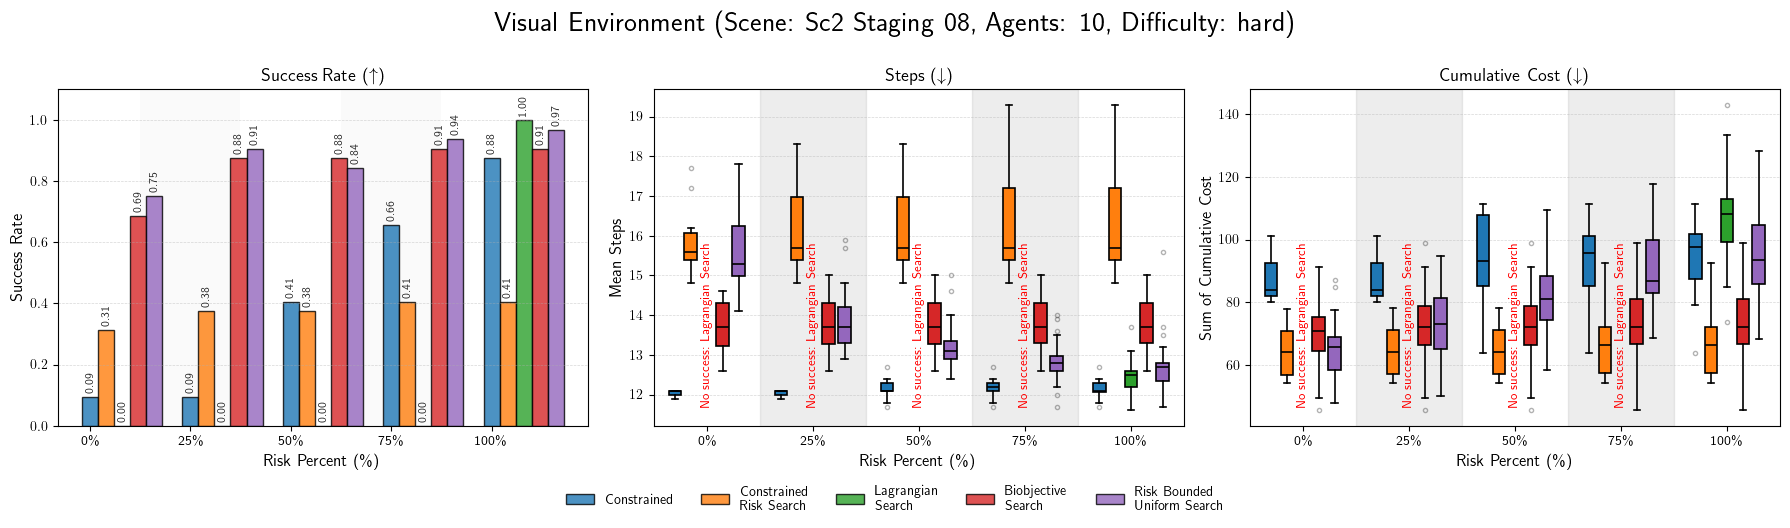

Processing data for sc0_staging_20
Processing data for 5 agents in easy problem type


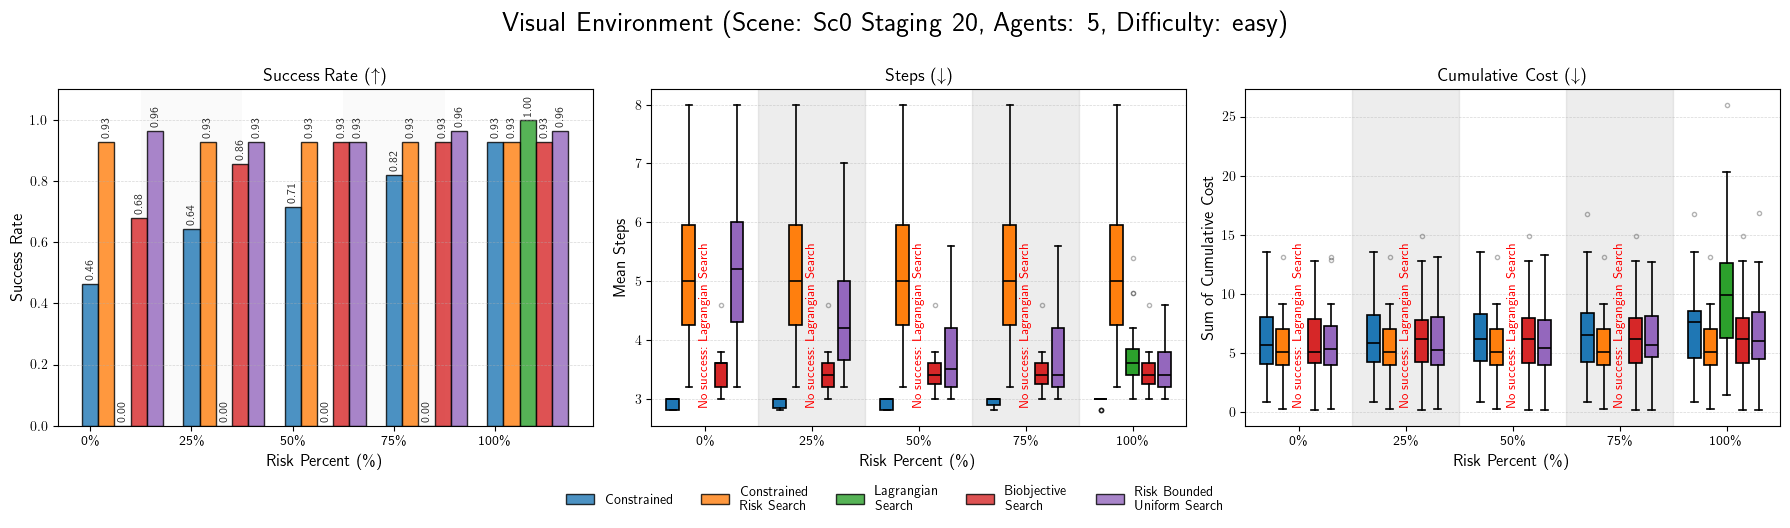

Processing data for 10 agents in easy problem type


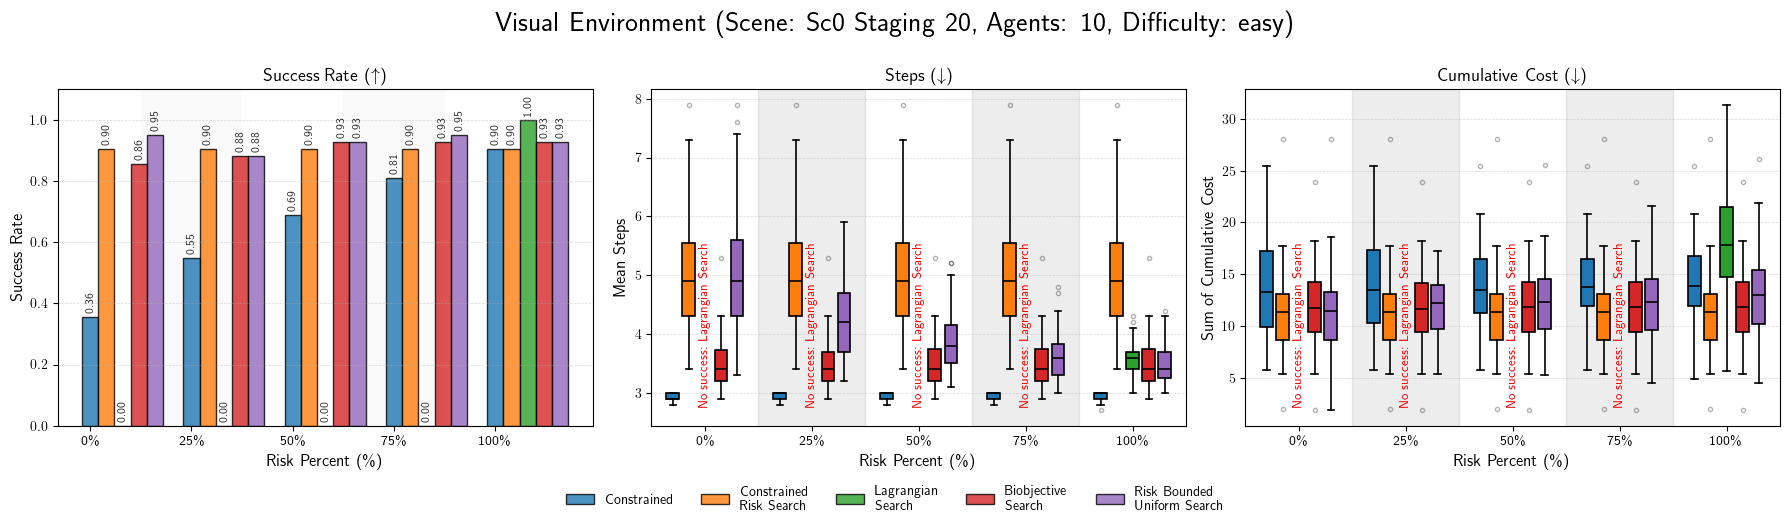

Processing data for 5 agents in medium problem type


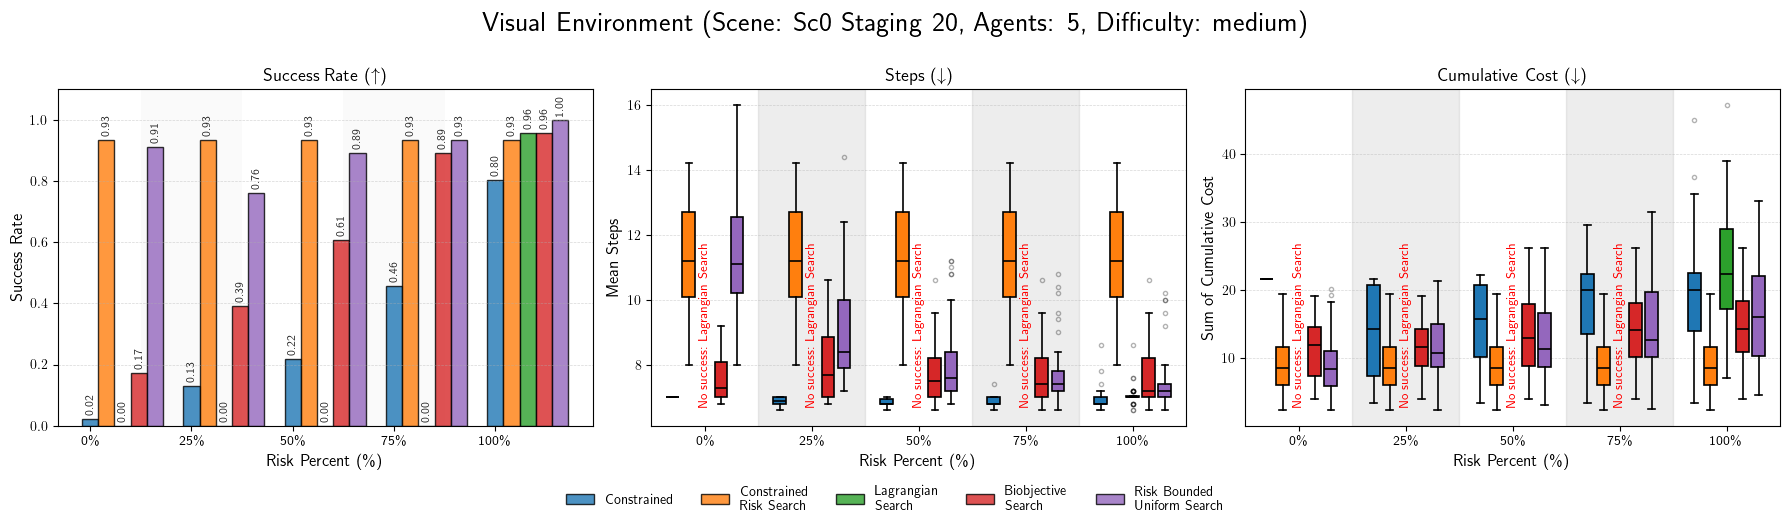

Processing data for 10 agents in medium problem type


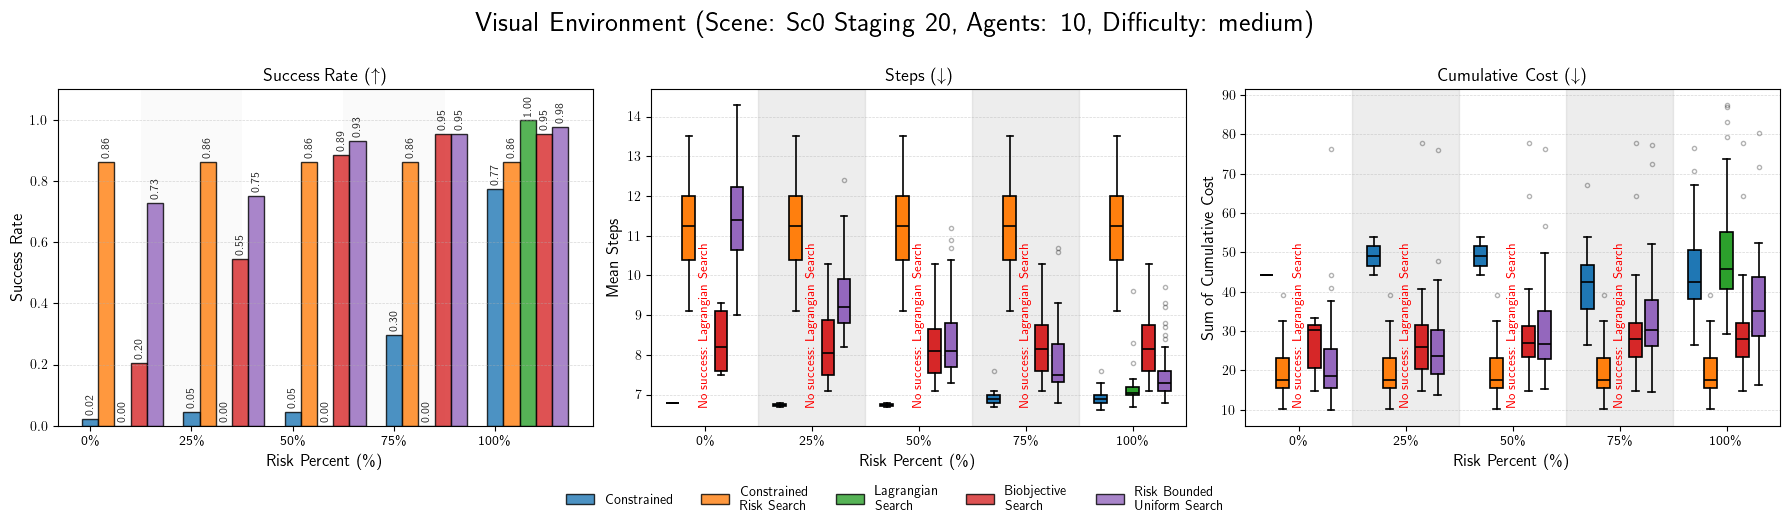

Processing data for 5 agents in hard problem type


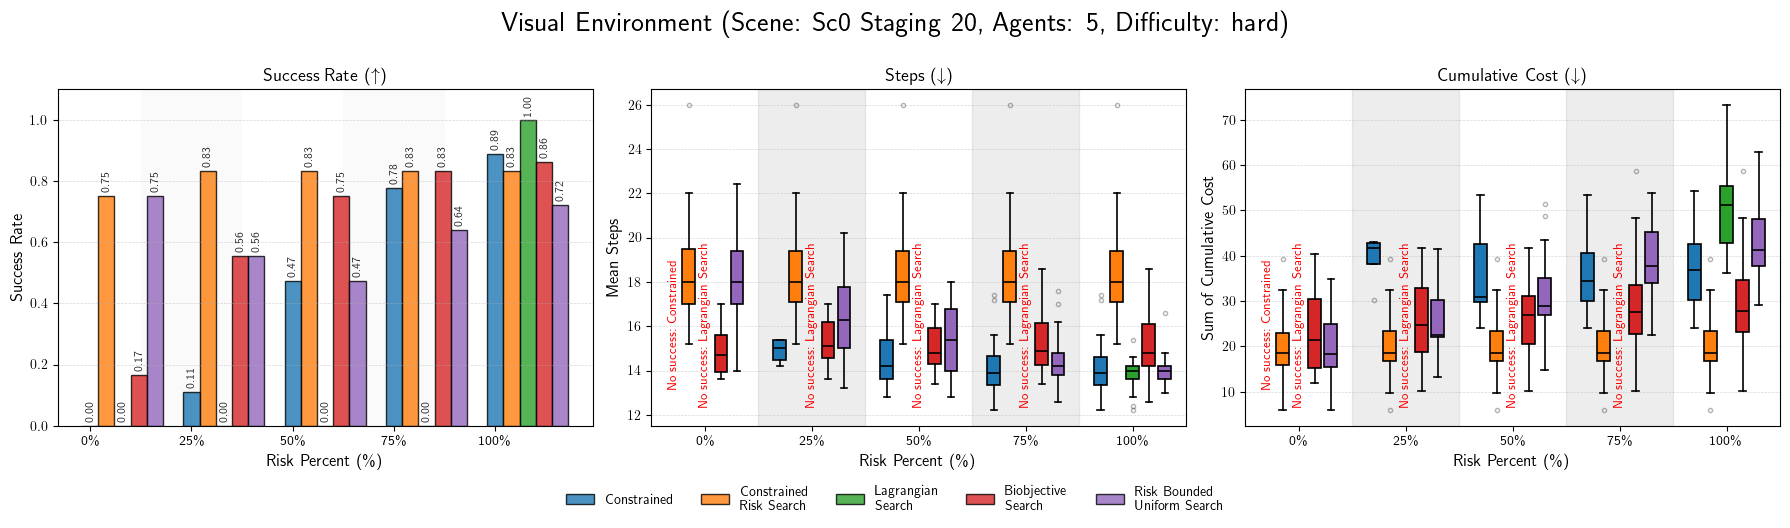

Processing data for 10 agents in hard problem type


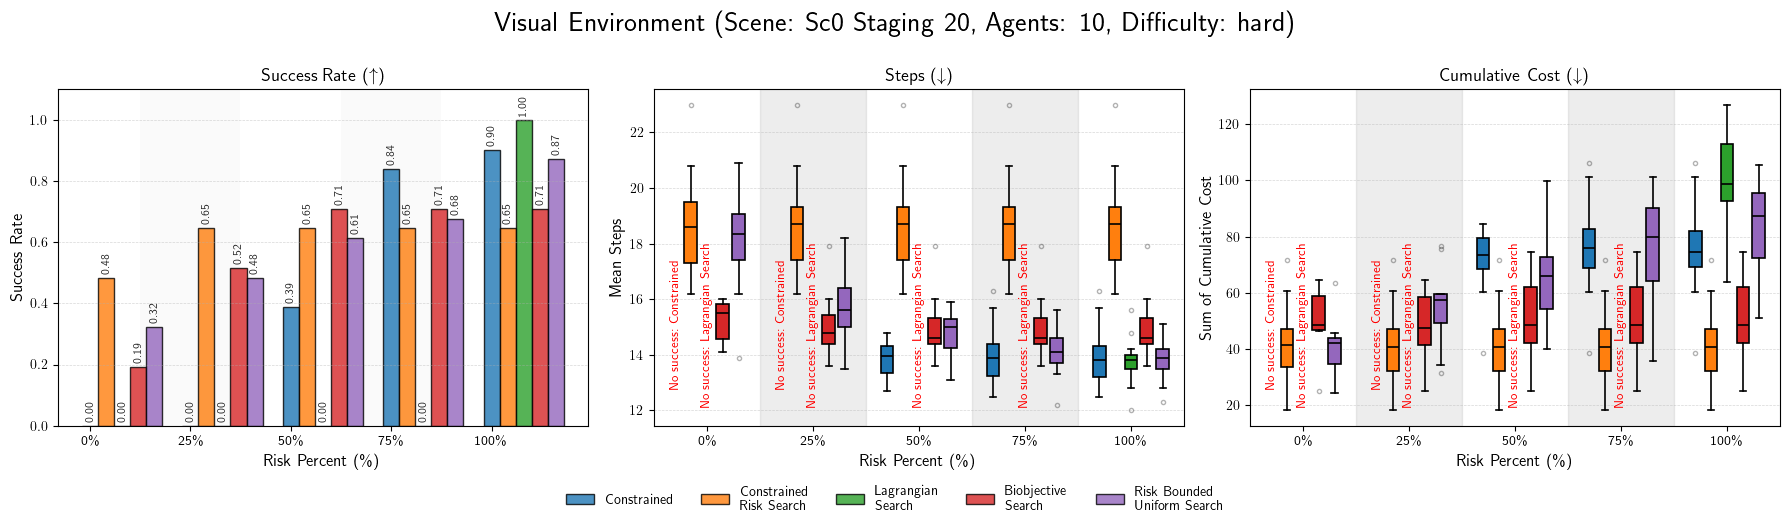

Processing data for sc3_staging_05
Processing data for 5 agents in easy problem type


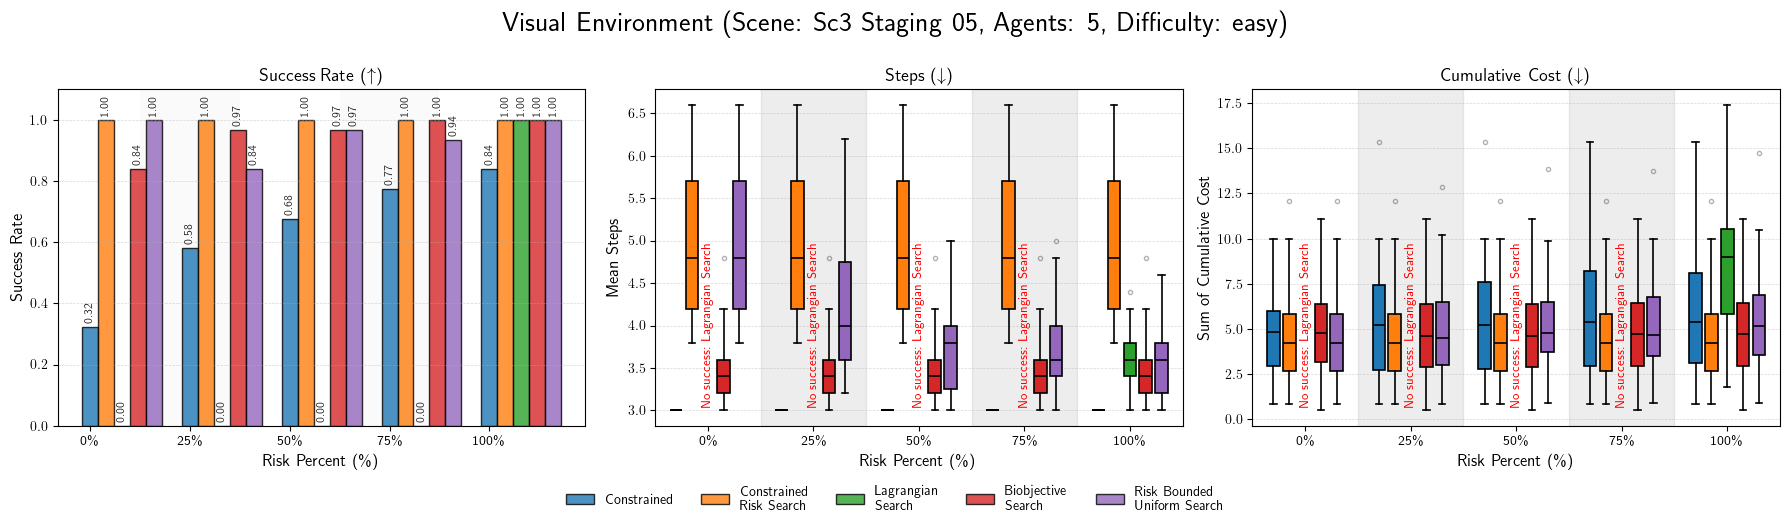

Processing data for 10 agents in easy problem type


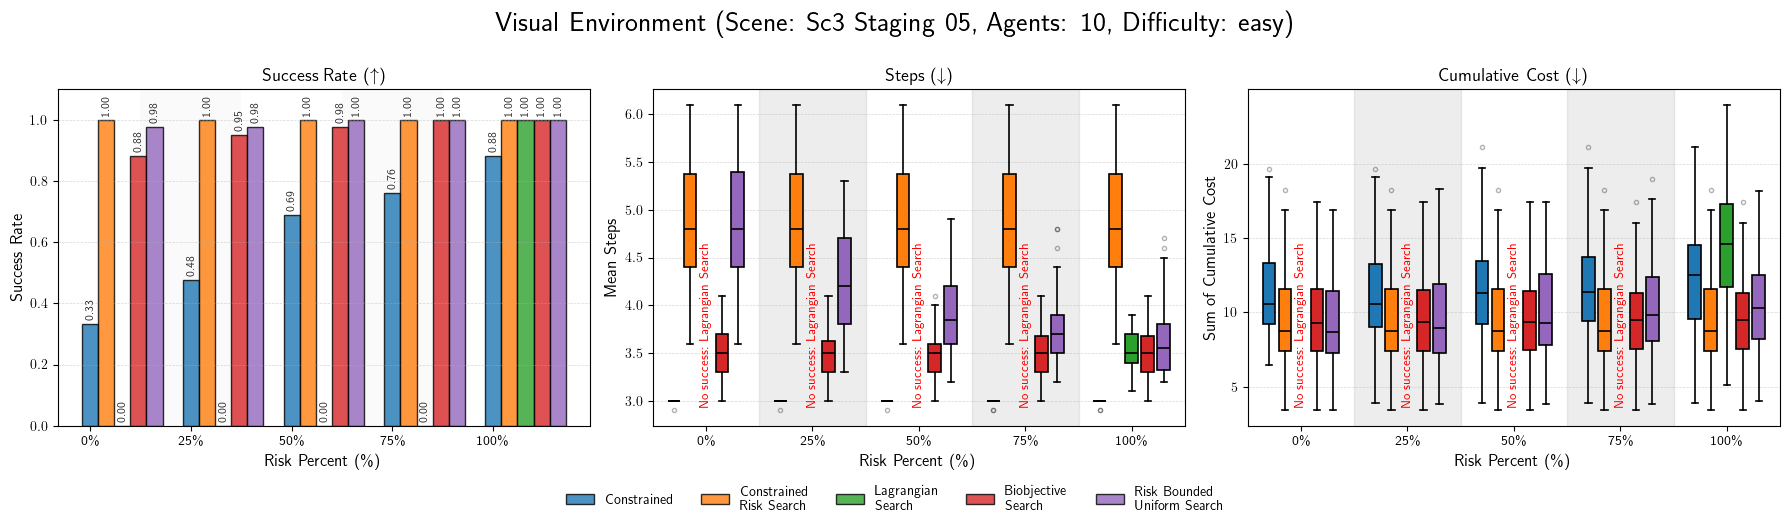

Processing data for 5 agents in medium problem type


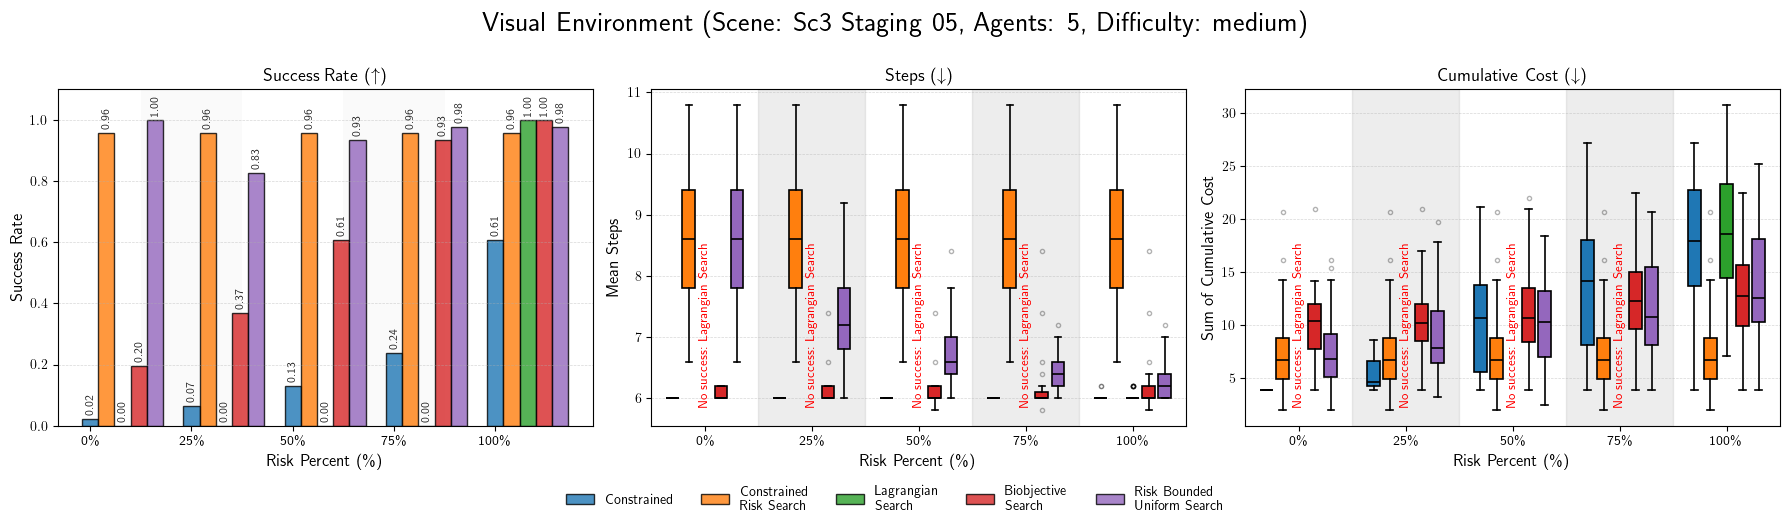

Processing data for 10 agents in medium problem type


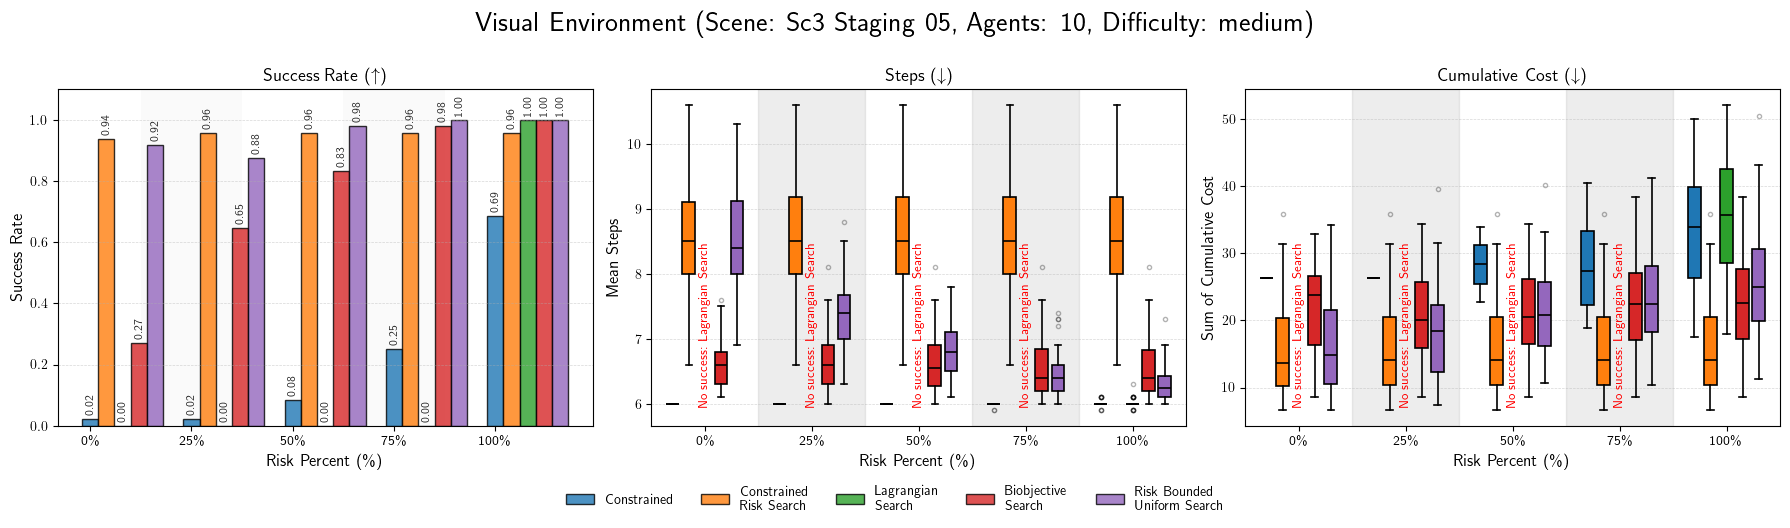

Processing data for 5 agents in hard problem type


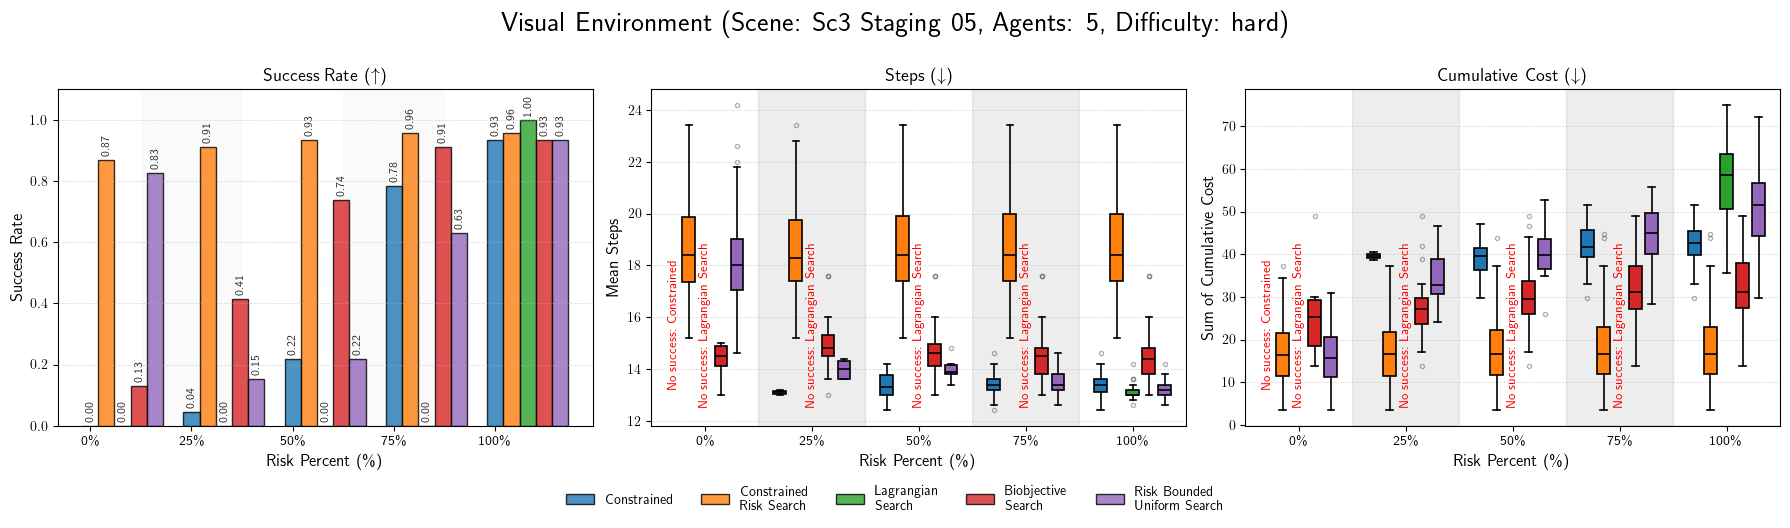

Processing data for 10 agents in hard problem type


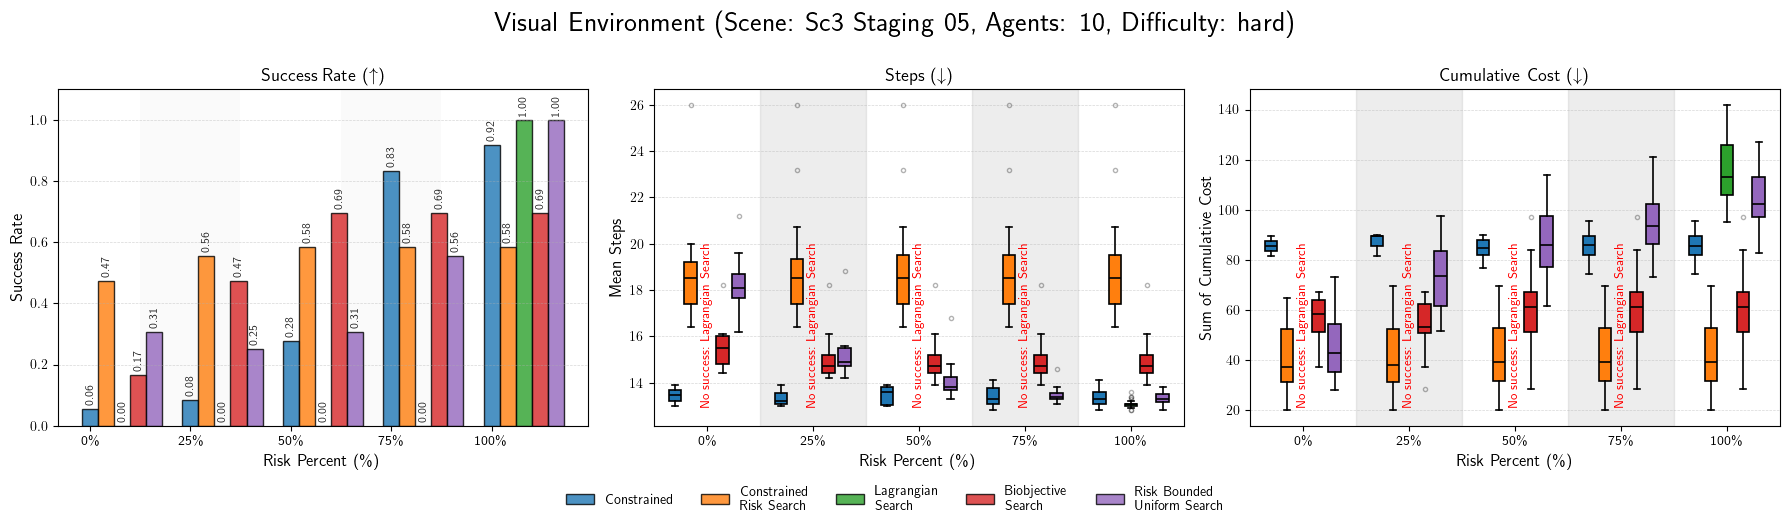

Processing data for sc3_staging_11
Processing data for 5 agents in easy problem type


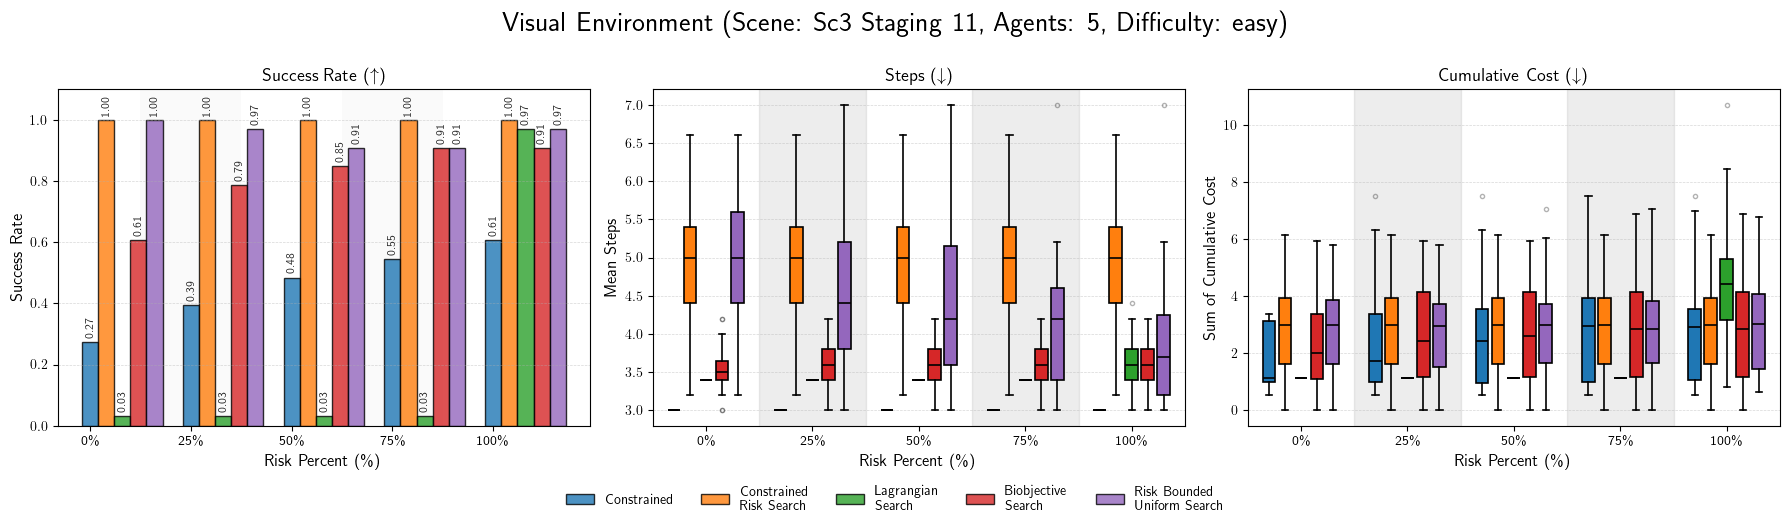

Processing data for 10 agents in easy problem type


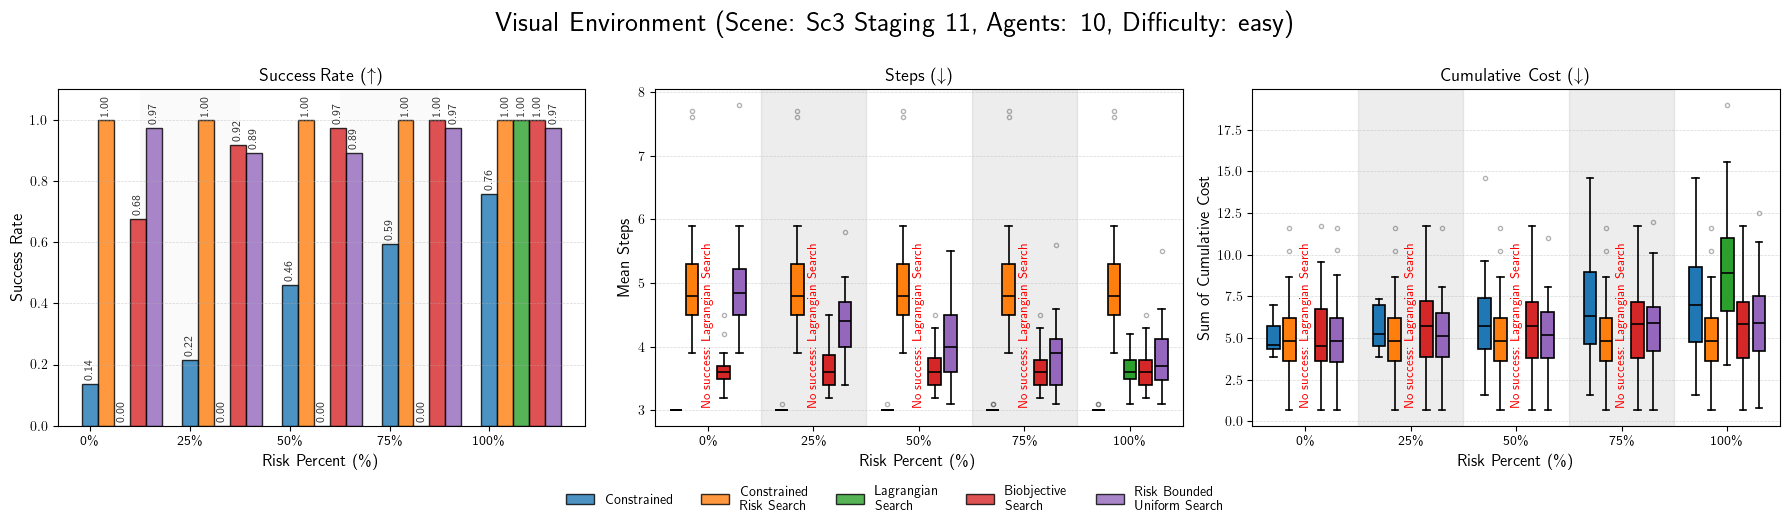

Processing data for 5 agents in medium problem type


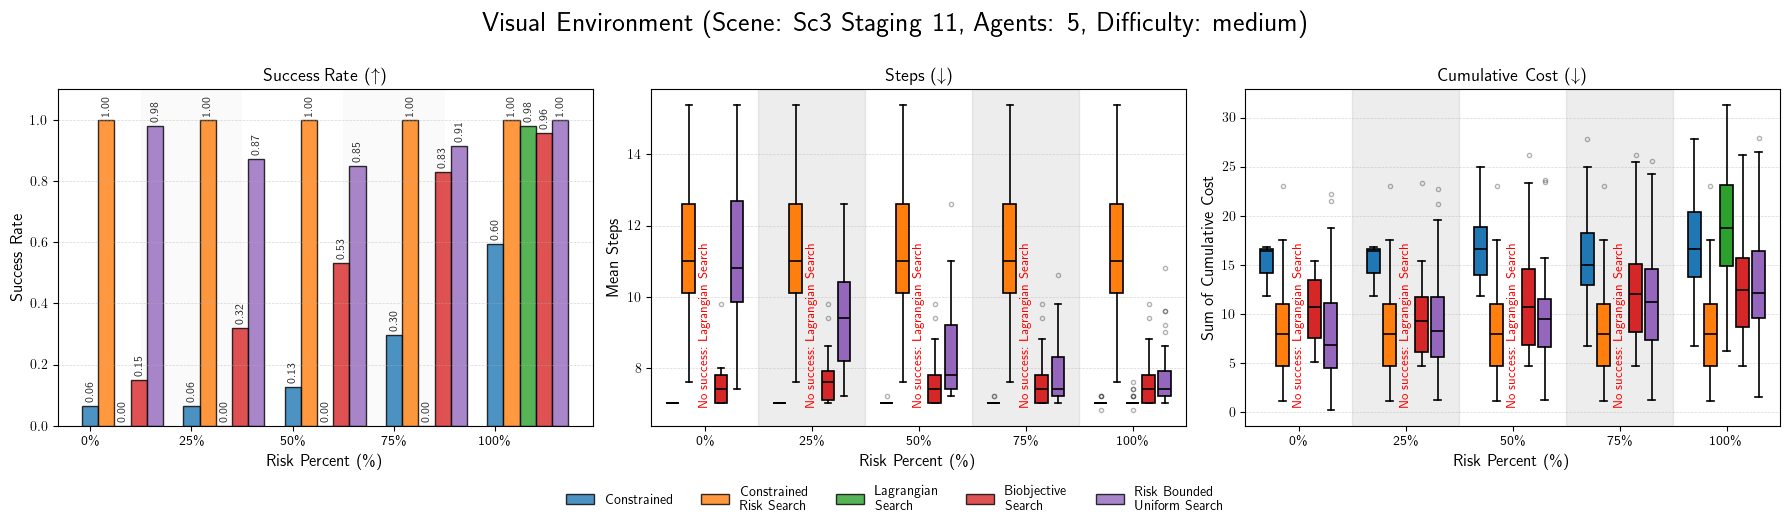

Processing data for 10 agents in medium problem type


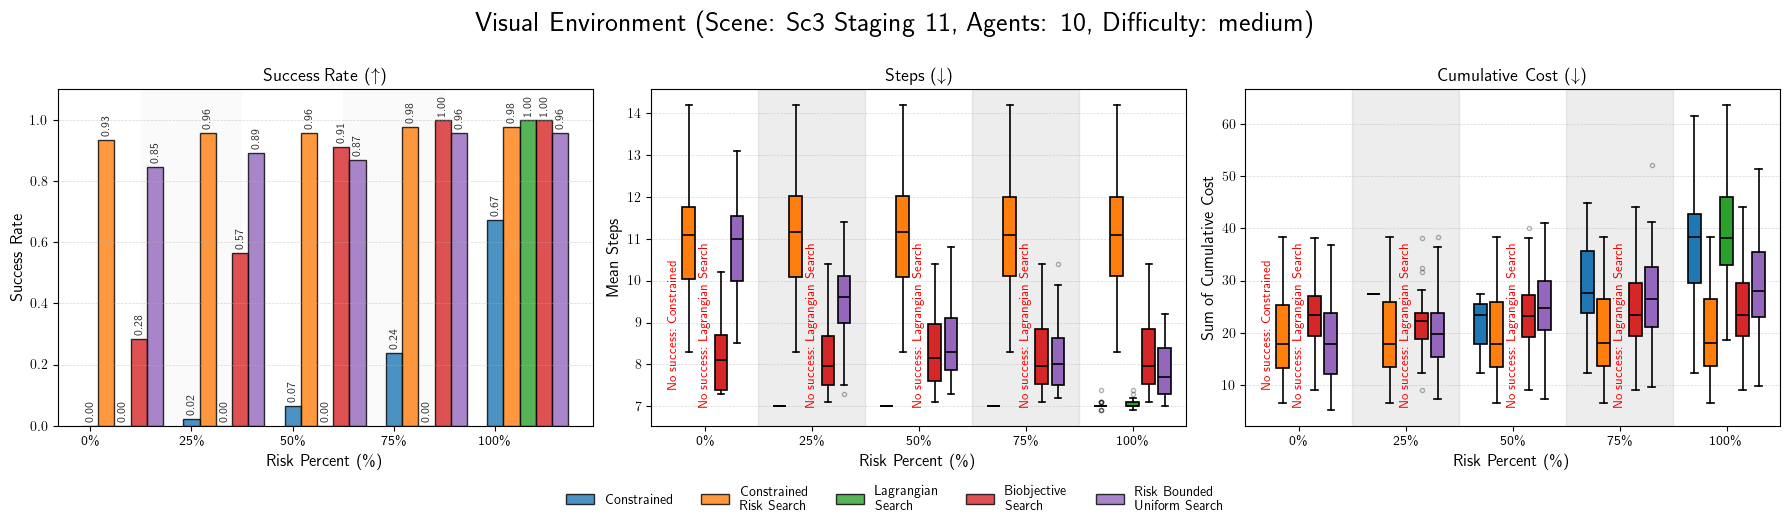

Processing data for 5 agents in hard problem type


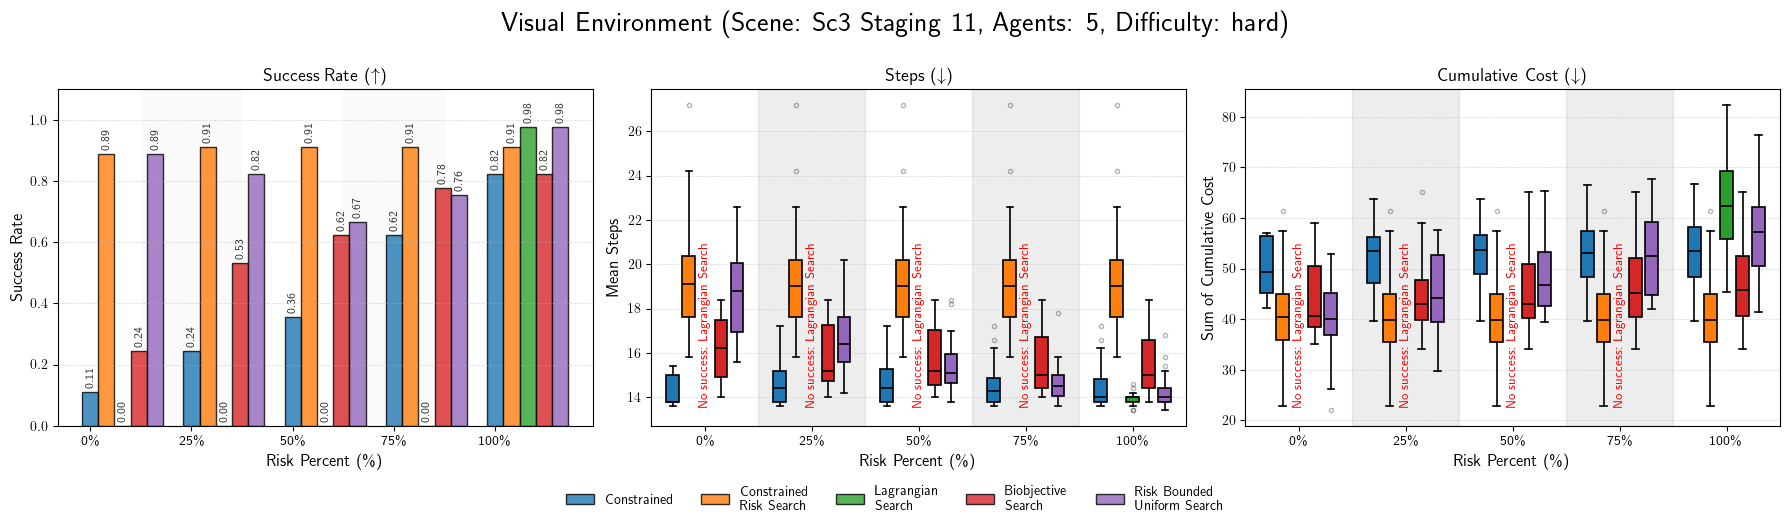

Processing data for 10 agents in hard problem type


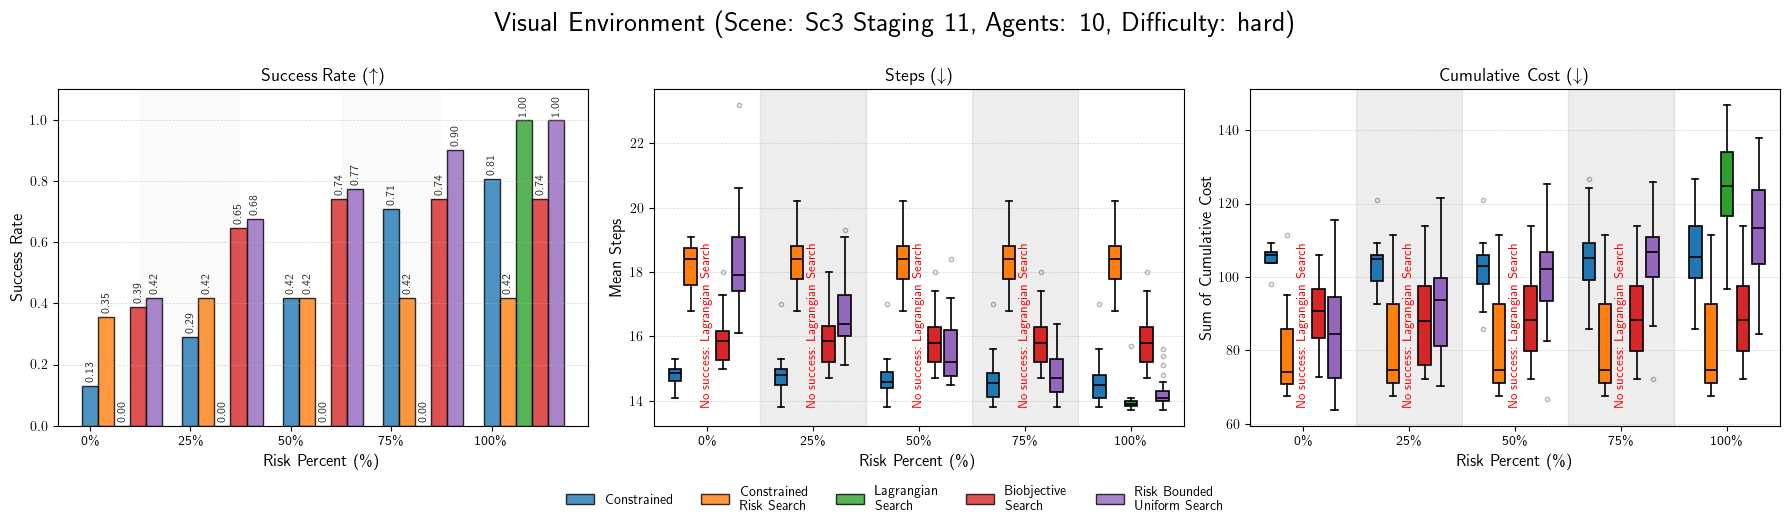

Processing data for sc3_staging_15
Processing data for 5 agents in easy problem type


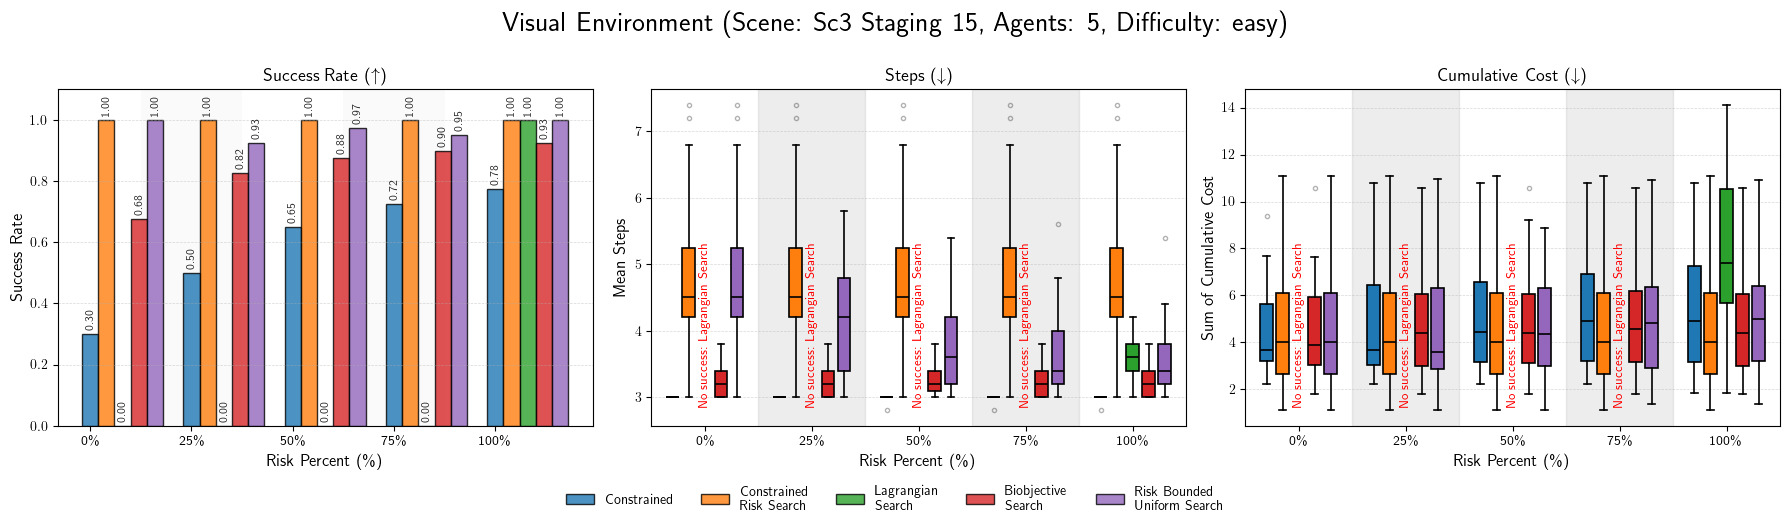

Processing data for 10 agents in easy problem type


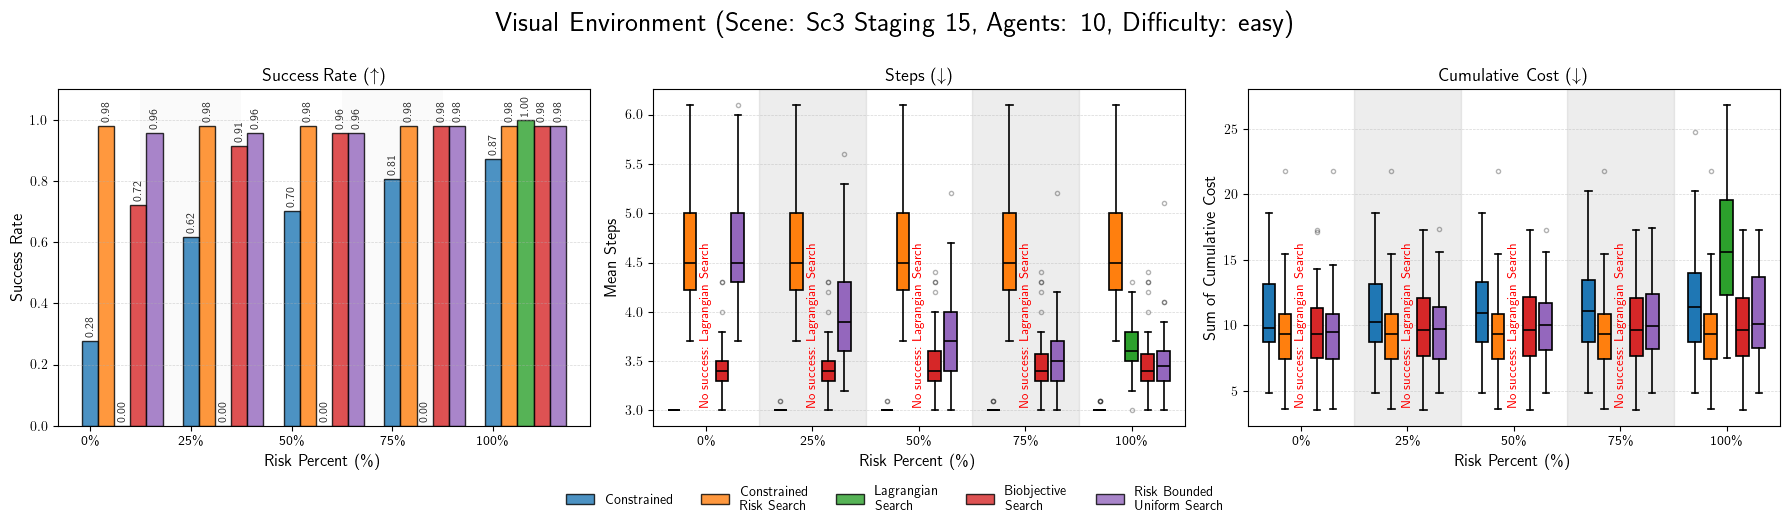

Processing data for 5 agents in medium problem type


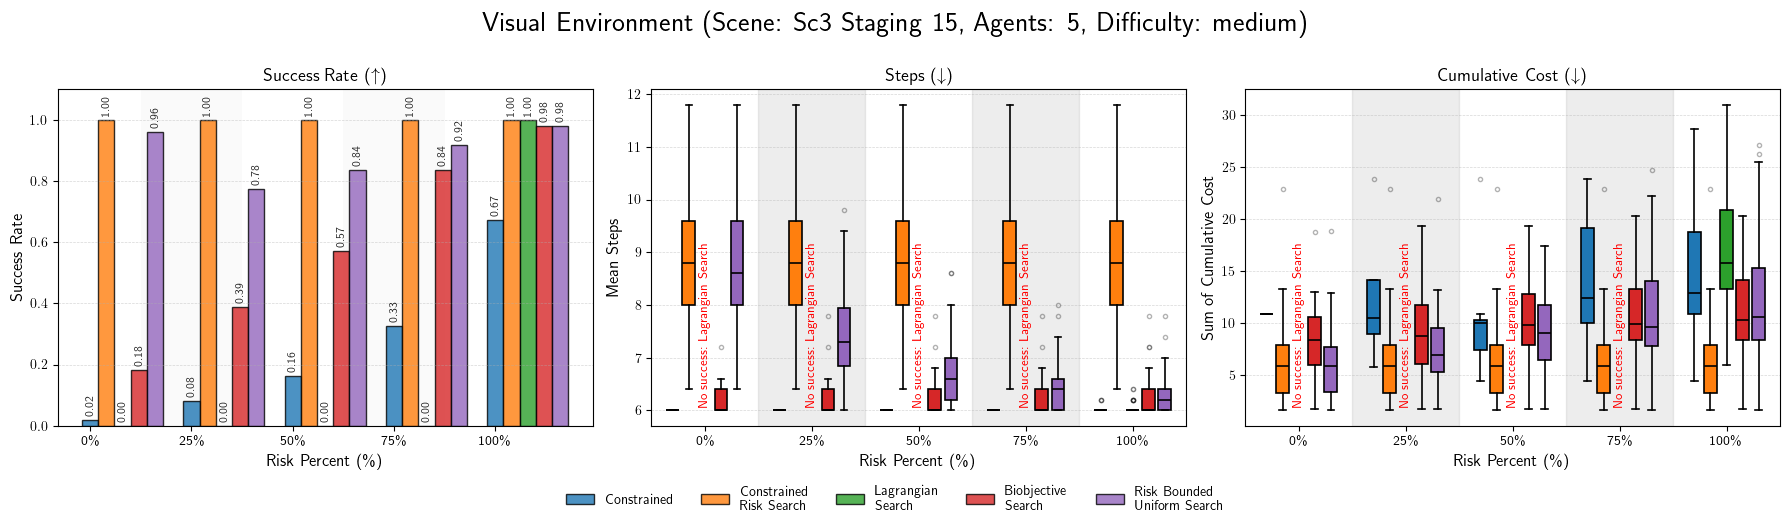

Processing data for 10 agents in medium problem type


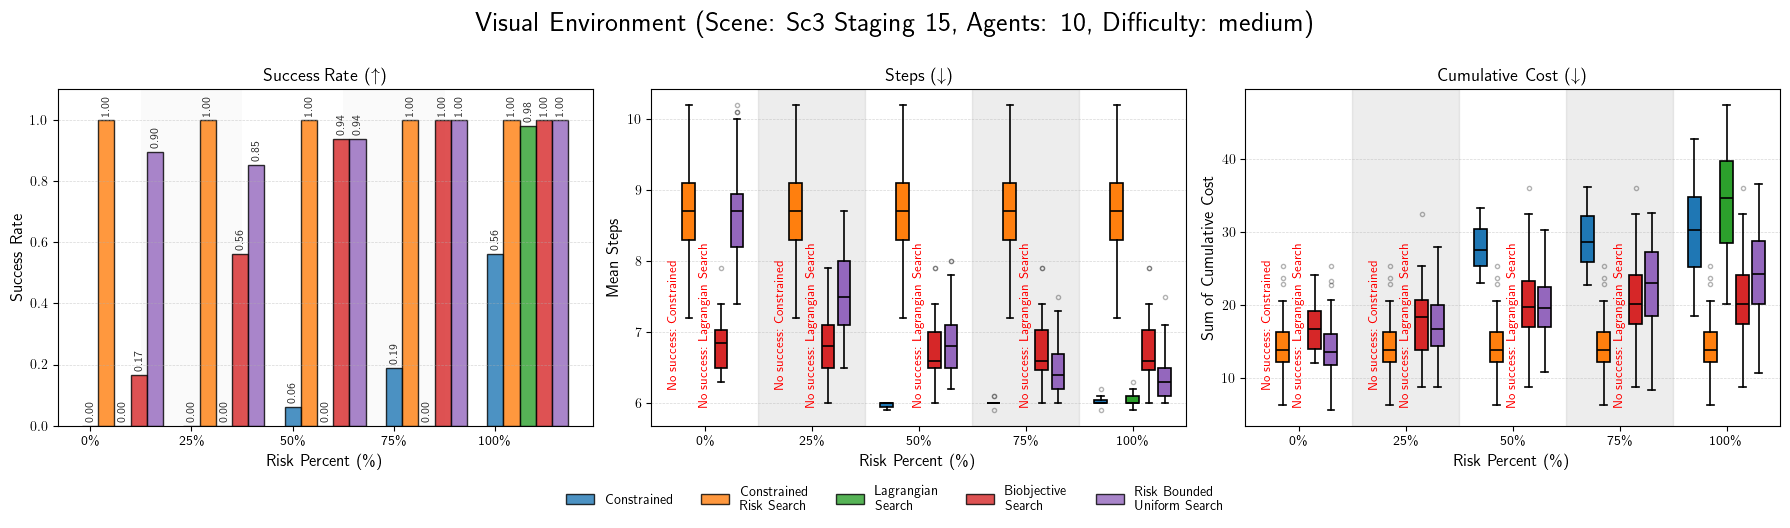

Processing data for 5 agents in hard problem type


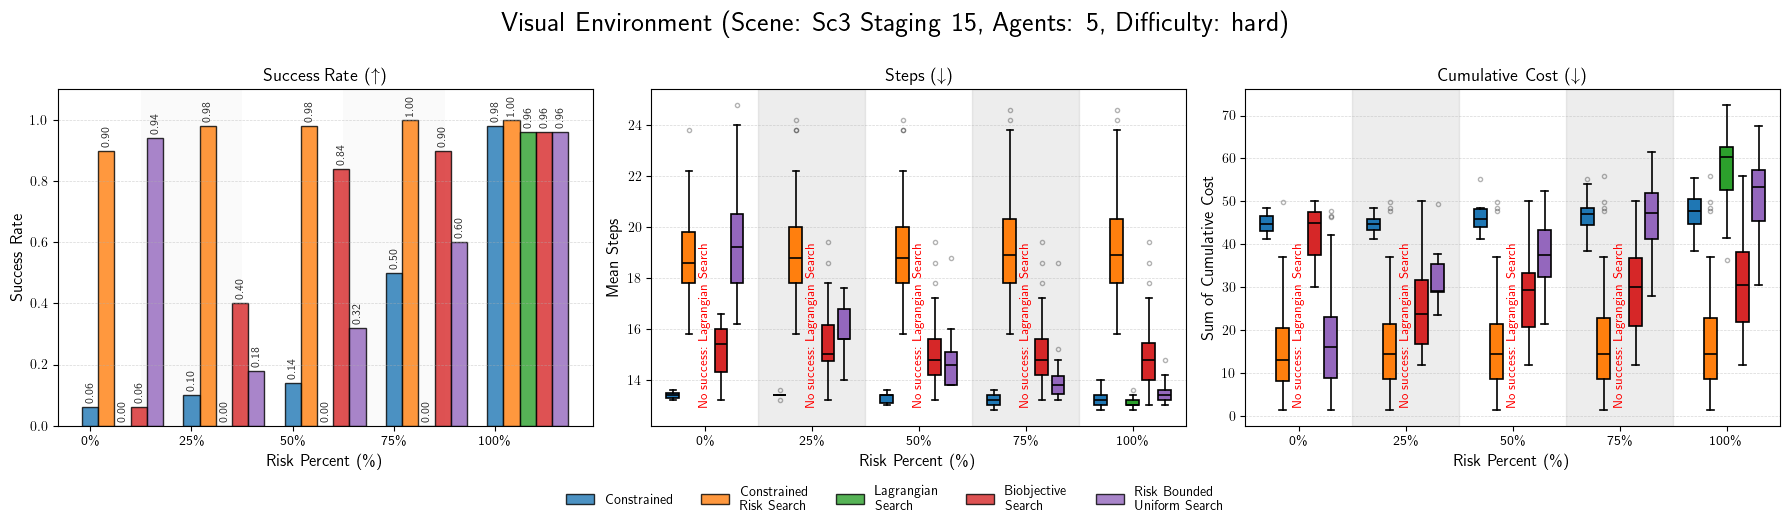

Processing data for 10 agents in hard problem type


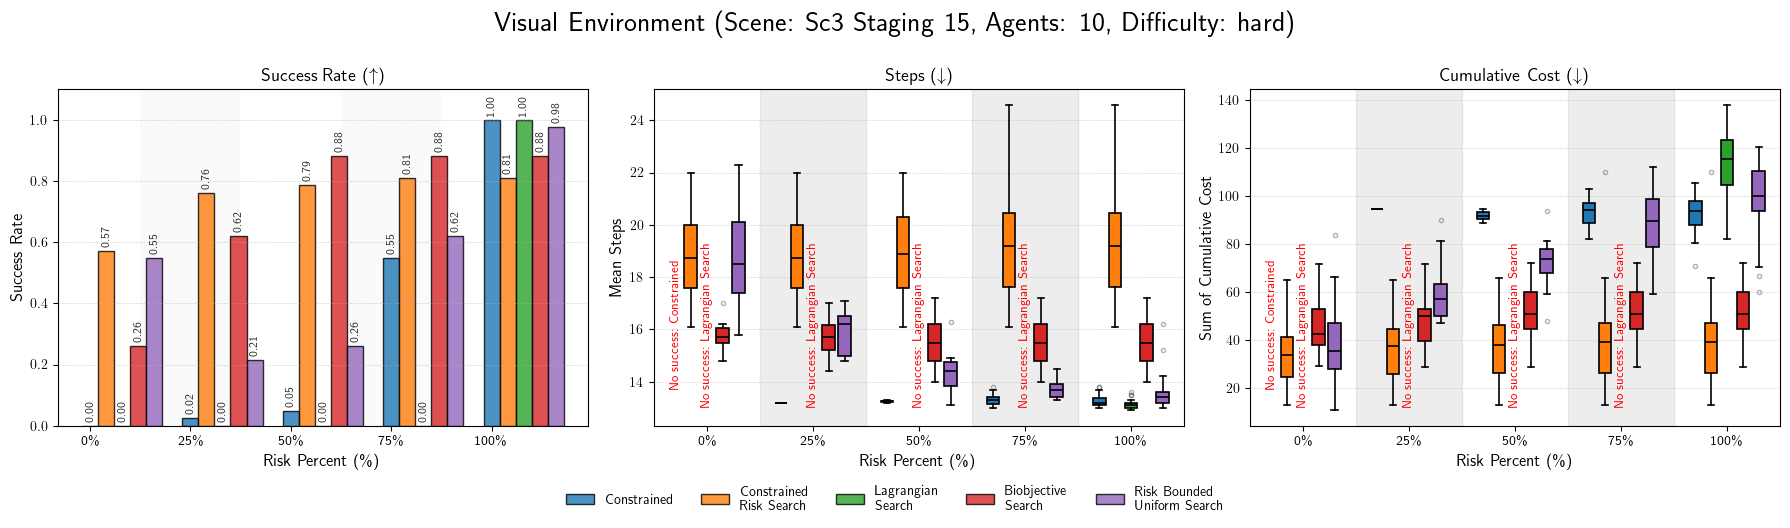

In [29]:
for envs in ["sc2_staging_08", "sc0_staging_20", "sc3_staging_05", "sc3_staging_11", "sc3_staging_15"]:
    basedir = Path("pud/plots/data/" + envs + "_icra")
    print(f"Processing data for {envs}")
    for problem_type in ["easy", "medium", "hard"]:
        for n_agents in [5, 10]:
            save = True if problem_type == "hard" and n_agents == 10 else False
            print(f"Processing data for {n_agents} agents in {problem_type} problem type")
            metrics_over_buckets = process_data(basedir, n_agents, problem_type)
            plot_data(metrics_over_buckets, envs, save=save)
            plt.show()

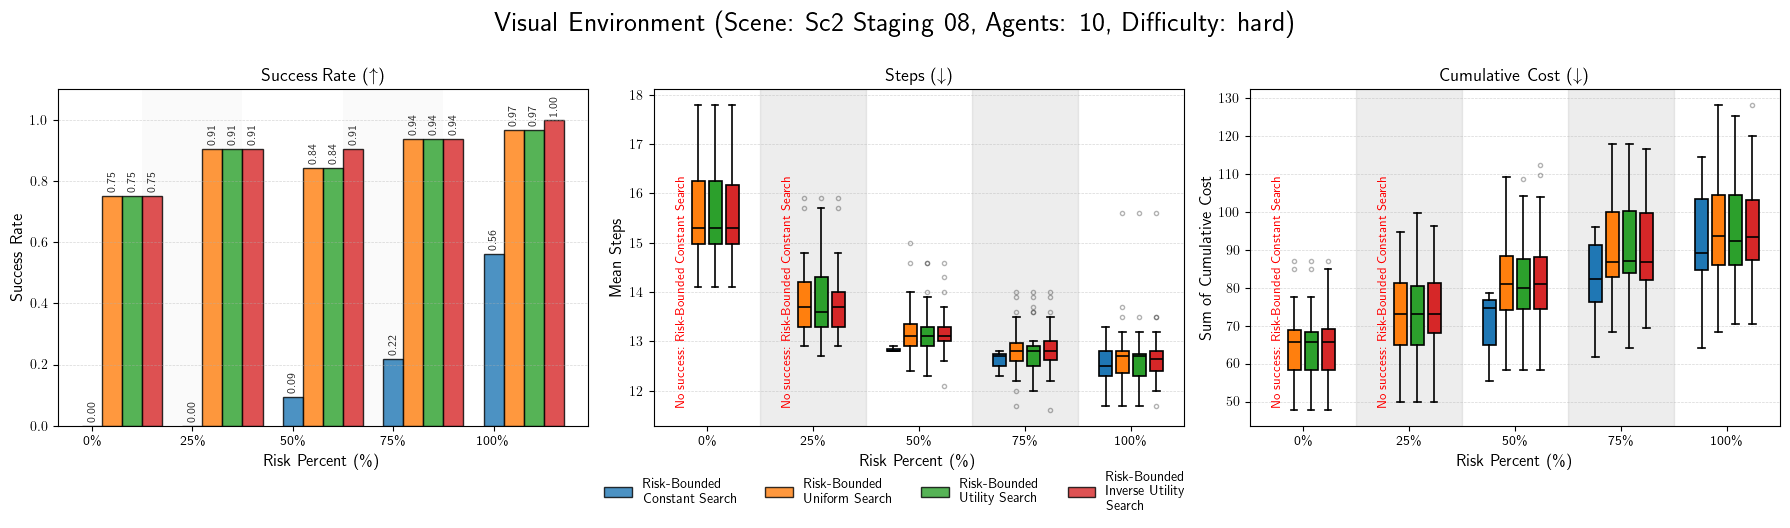

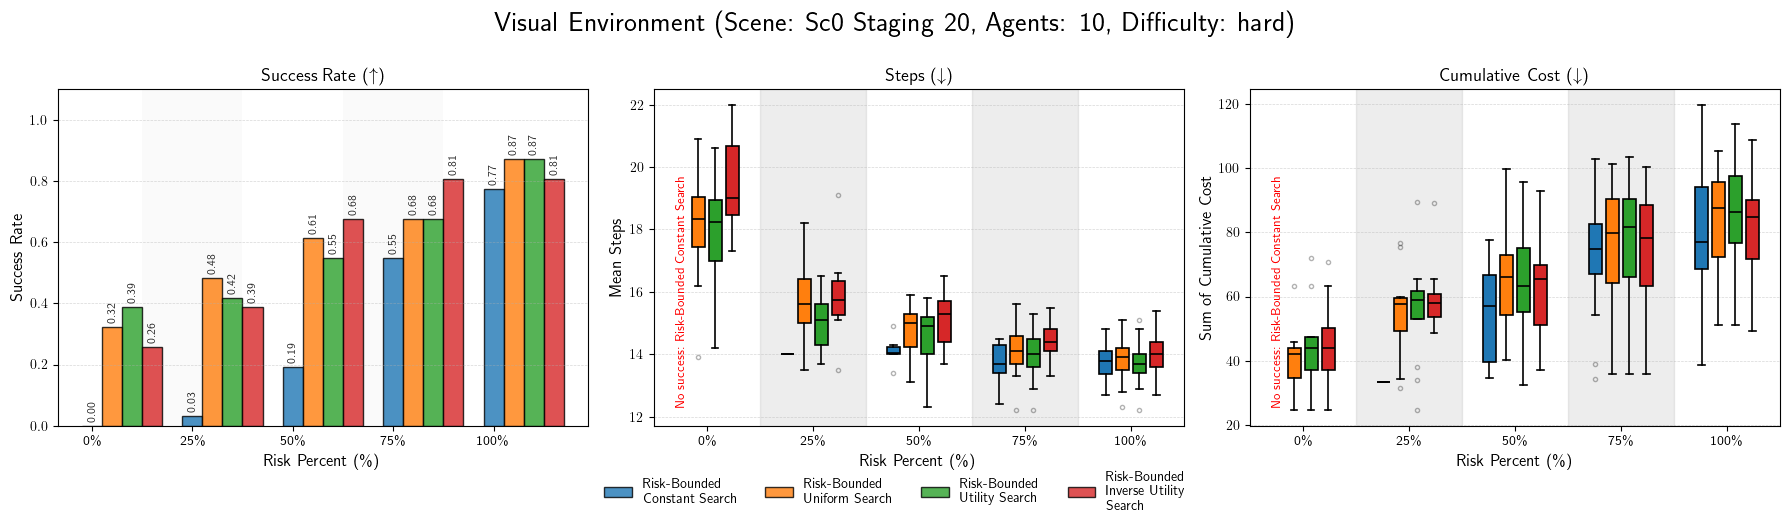

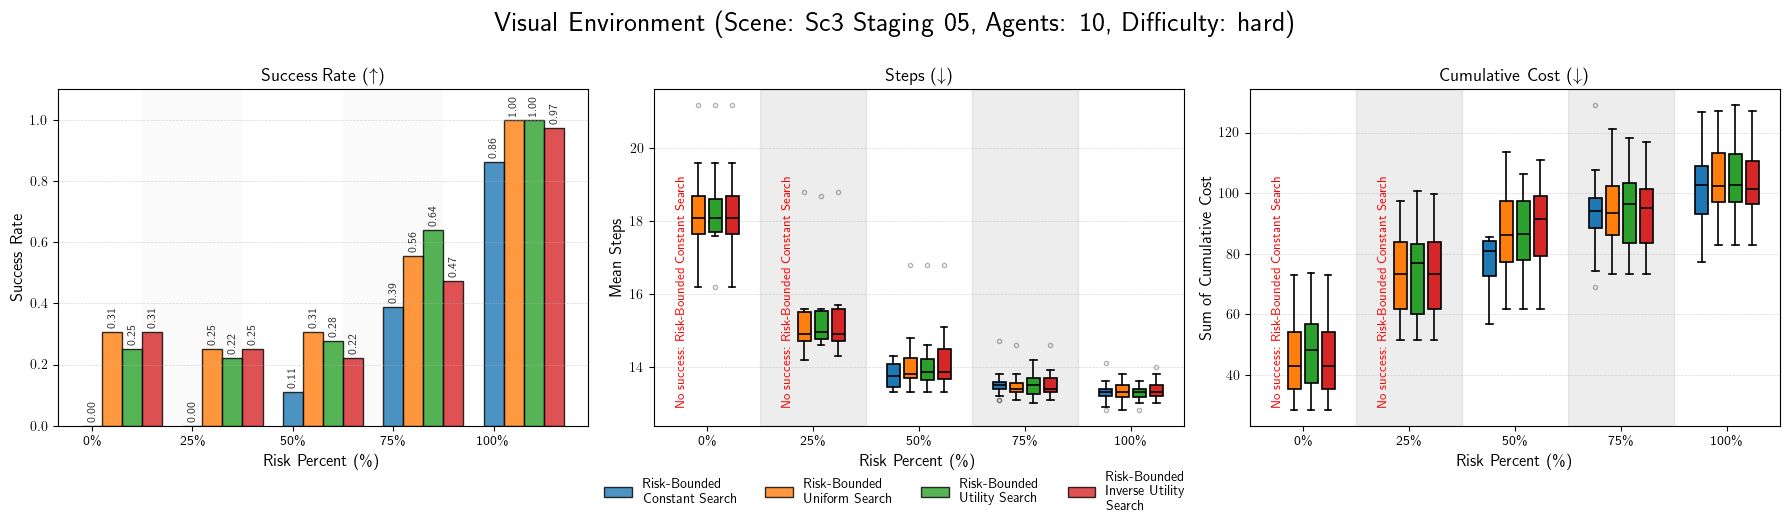

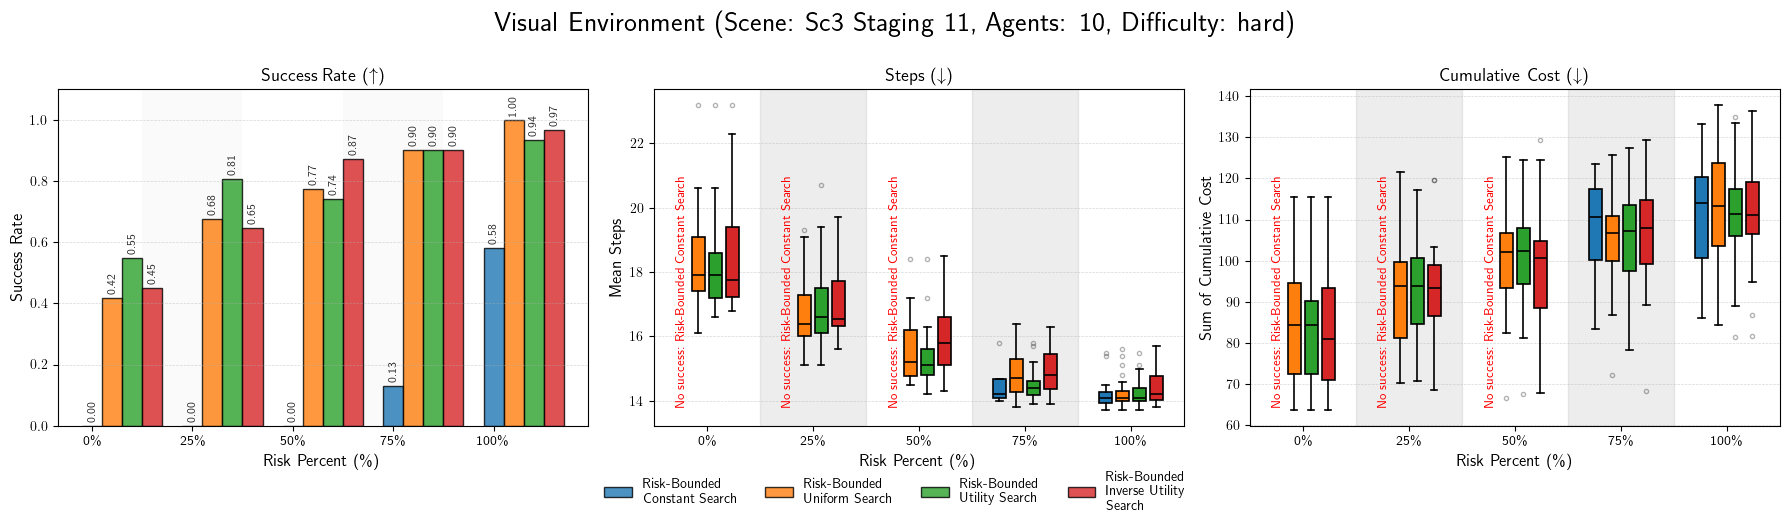

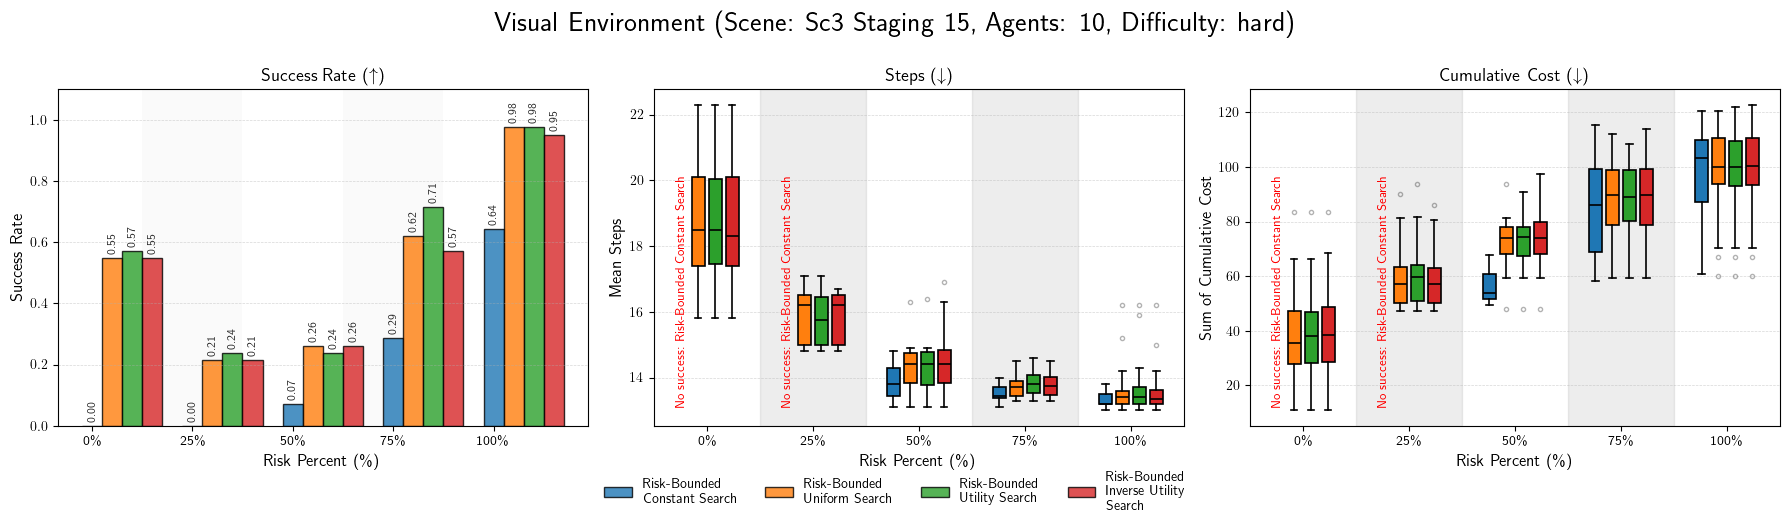

In [32]:
method_titles = ["Risk-Bounded\nConstant Search", "Risk-Bounded\nUniform Search", "Risk-Bounded\nUtility Search", "Risk-Bounded\nInverse Utility\nSearch"]
methods = []
rb_methods = [
    "risk_budgeted_search",
    "risk_bounded_uniform_search",
    "risk_bounded_utility_search",
    "risk_bounded_inverse_utility_search",
]
for envs in ["sc2_staging_08", "sc0_staging_20", "sc3_staging_05", "sc3_staging_11", "sc3_staging_15"]:
    basedir = Path("pud/plots/data/" + envs + "_icra")
    metrics_over_buckets = process_data(basedir, 10, "hard")
    plot_data(metrics_over_buckets, env_name=envs, save=False)